# Phytoplankton Phenology Study in the Northwest Atlantic Ocean

#### Import Python Libraries

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy
import pandas as pd
from shapely.ops import unary_union
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import mapping
from shapely.geometry import Polygon
import rioxarray
import sys
sys.path.append(r'C:\Users\grace.davis\Documents\GitHub\RESOURCES\python')
import utilities
from utilities import get_prod_files
import cmocean
from matplotlib.colors import LogNorm
import cartopy.crs as crs
import statsmodels as sm
from statsmodels import nonparametric
from statsmodels.nonparametric import smoothers_lowess
import scipy
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import argrelextrema
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
from collections import Counter
import plotly.express as px
import seaborn as sns
import calendar
import plotly.graph_objects as go
import plotly.colors
from scipy import stats

In [2]:
daily_data = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr',consolidated=True)
MABS = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\MABS_smoother_tests.zarr')
MABN = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\MABN_smoother_tests.zarr')
GB = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\GB_smoother_tests.zarr')
GOMW = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\GOMW_smoother_tests.zarr')
GOME = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\GOME_smoother_tests.zarr')

In [3]:
shapefile = gpd.read_file('https://github.com/hsynan/READ-EDAB-Synan_hydrographic_climatologies/raw/refs/heads/main/data/shapefiles/NES_5REGIONS.zip')
MAB_south_loc = shapefile.iloc[[0]].set_crs("epsg:4326", inplace=True)
MAB_north_loc = shapefile.iloc[[1]].set_crs("epsg:4326", inplace=True)
GB_whole_loc = shapefile.iloc[[2]].set_crs("epsg:4326", inplace=True)
GOM_west_loc = shapefile.iloc[[3]].set_crs("epsg:4326", inplace=True)
GOM_east_loc = shapefile.iloc[[4]].set_crs("epsg:4326", inplace=True)
NES = shapefile.dissolve()

## Part 1: Bloom Detection Method Testing

### Threshold Method

#### Function for determining the climatological threshold value

In [4]:
def threshold_value(thld = 0.1, path = None):
    """
    Calculates the threshold value for chlorophyll-a based on a median baseline provided by the regional climatology.

    If no file path is provided, the path defaults to grabbing and reading the annual climatology file for the Northeast Shelf (NES) region. 
    The threshold is calculated by finding the percentage above the climatological CHL median for each pixel in the region.

    Args:
        thld (float, optional): The fraction value of the percentage above the median. This value defaults to 0.1 (10%).
        path (str, optional): The path to netCDF file used to calculate the threshold value. Defaults to None.

    Returns:
        xarray.DataArray: A spatial array containing the threshold values for each coordinate based on the median CHL value
    """
    if path is None:
        file = get_prod_files('CHL',mapping='NES',period='ANNUAL') #finds path for the annual climatology file
        base_ds = xr.open_dataset(file[0]) #opens netCDF file
    else:
        base_ds = xr.open_dataset(path)
    median_CHL = base_ds.CHL_median #grabs CHL_median variable
    thld_value = median_CHL*(1+thld) #Sets threshold value per latitude and longitude point
    return thld_value

In [5]:
def spatial_threshold_value(shapefile_geometry,thld=0.1,path=None):
    """
    Creates a threshold value for a spatially averaged area.

    Using the threshold value, this function creates a spatially averaged threshold value for a region for use in other analysis.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        thld (float, optional): Percentage for threshold calcultion. Defaults to 0.1.
        path (str, optional): Path to climatology file. Defaults to None.
    
    Returns:
        float. Value of the regionally averaged chlorophyll threshold.
    """
    threshold = threshold_value(thld=thld,path=path)
    threshold.rio.write_crs("EPSG:4326",inplace=True)
    threshold.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    shapefile = shapefile_geometry.to_crs("EPSG:4326")
    clipped_thld = threshold.rio.clip(shapefile.geometry.apply(mapping), shapefile.crs, drop=True)
    clipped_thld = clipped_thld.mean(dim=['lat','lon'])
    clipped_thld = clipped_thld.item()
    return clipped_thld

In [6]:
MABS_clipped_thld = spatial_threshold_value(MAB_south_loc,thld=0.1)
MABN_clipped_thld = spatial_threshold_value(MAB_north_loc,thld=0.1)
GB_clipped_thld = spatial_threshold_value(GB_whole_loc,thld=0.1)
GOMW_clipped_thld = spatial_threshold_value(GOM_west_loc,thld=0.1)
GOME_clipped_thld = spatial_threshold_value(GOM_east_loc,thld=0.1)
MABS_clipped_med = spatial_threshold_value(MAB_south_loc,thld=0)
MABN_clipped_med = spatial_threshold_value(MAB_north_loc,thld=0)
GB_clipped_med = spatial_threshold_value(GB_whole_loc,thld=0)
GOMW_clipped_med = spatial_threshold_value(GOM_west_loc,thld=0)
GOME_clipped_med = spatial_threshold_value(GOM_east_loc,thld=0)

📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.

#### Plotting the Climatological Threshold

In [ ]:
clim_med = threshold_value().squeeze()
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
fig = plt.figure(figsize=(15,8))
map_projection = cartopy.crs.PlateCarree()
ax = plt.axes(projection=map_projection)
im = plt.pcolormesh(clim_med.lon,
                    clim_med.lat,
                    clim_med,
                    cmap=cmocean.cm.algae,
                    norm=LogNorm(vmin=0.1, vmax=10.0)
)
custom_ticks = [0.1,1,10]
cb = plt.colorbar(im,shrink=0.8,label='Chlorophyll a Threshold ($mg/m^3$)',ticks=custom_ticks,format='%g') #$ $ makes it a LaTEX function so it actually formats as an equation

ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
ax.set_extent([-77,-62,37,47])
ax.gridlines(draw_labels=True)
ax.set_title('Chlorophyll a Climatological Median Threshold', fontsize=24)

#### Create a mask to filter data for bloom conditions

In [8]:
def bloom_mask(path=None,thld=0.1,clim_path=None,Boolean=False): #Produces True and False values
    """
    Creates a mask on the chlorophyll-a data to only include values above the threshold set by the climatological median.

    If no file path is provided, the function searches for all D8 files (8 day rolling mean) for the Northeast Shelf. 
    If a file path is provided, it is currently set to open zarr files. The code exists to open netCDFs as well, it just needs to be uncommented. 
    If no climatology file path is provided, the function searches for the annual climatology file of the Northeast Shelf region.
    The median chlorophyll-a values are then extracted and compared to the threshold value found from the regional climatology.
    If the median chlorophyll-a values exceed the threshold, the value is stored as true. Otherwise, it is stored as false.

    Args:
        path (str, optional): Path to the daily data (or other temporal resolution data). Defaults to None
        thld (float, optional): Fractional value for percentage to calculate the climatological threshold per coordinate. Defaults to 0.1 (10%)
        clim_path (str, optional): Path to regional climatology file. Defaults to None
        Boolean (bool, optional): Determines how values are stored. False keeps the actual values and marks false values as 0. True stores an array of True and False values. Defaults to False

    Returns:
        xarray.DataArray: A spatial array with Boolean values or floats for each coordinate based on the threshold value.
    """
    if path is None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NES
        ds = xr.open_mfdataset(files)
    else:
        #ds = xr.open_mfdataset(path)
        ds = xr.open_zarr(path)
    if Boolean is True:
        med_CHL = ds.CHL_median #Extracts CHL_median variable for the files
        clim_med = threshold_value(thld=thld,path=clim_path)
        is_bloom_CHL = med_CHL > clim_med #Is the median chl-a in each files greater than the climatological mean? Creates a Boolean array of trues and falses.
    else:
        med_CHL = ds.CHL_median #Extracts CHL_median variable for the files
        clim_med = threshold_value(thld=thld,path=clim_path)
        clim_med_new = clim_med.isel(time=0, drop=True) #Removes time dimension from climatological mean
        is_bloom_CHL = med_CHL.where(med_CHL > clim_med_new, 0) #Turns false into 0 and trues retain their value
    return is_bloom_CHL

#### Mask Intervals
Finding the climatological threshold at a few different inteverals (5%, 10%, 15%, 20%, 25%, and 30%)

In [ ]:
thld_value = [0.05,0.1,0.15,0.2,0.25,0.3]
clim_med = threshold_value()
bloom_5 = bloom_mask(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[1])
bloom_10 = bloom_mask(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[2])
bloom_15 = bloom_mask(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[3])
bloom_20 = bloom_mask(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[4])
bloom_25 = bloom_mask(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[5])
bloom_30 = bloom_mask(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')

Plotting all of the masks (5% - 30%)
<br> Must pick a day of the year from (INPUT VALUE RANGE HERE)

In [ ]:
DOY = 7181
datasets = [
    (bloom_5[DOY],"Chlorophyll a 5% Mask"),
    (bloom_10[DOY], "Chlorophyll a 10% Mask"),
    (bloom_15[DOY], "Chlorophyll a 15% Mask"),
    (bloom_20[DOY], "Chlorphyll a 20% Mask"),
    (bloom_25[DOY], "Chlorophyll a 25% Mask"),
    (bloom_30[DOY], "Chlorophyll a 30% Mask"),
    ]

fig, axes = plt.subplots(3,2,figsize=(14,12),subplot_kw={"projection":map_projection})
axes_flat = axes.flatten()

im= None

for i, (data,title) in enumerate(datasets):
    ax = axes_flat[i]
    im = ax.pcolormesh(data.lon,
                data.lat,
                data,
                cmap=cmocean.cm.algae,
                norm=LogNorm(vmin=0.1, vmax=10.0)
    )
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
    ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree())
    ax.set_xlabel('Longitude ($^o$)', fontsize=12)
    ax.set_ylabel('Latitude ($^o$)', fontsize=12)
    ax.set_extent([-77,-63,34.5,46])
    ax.set_title(title, fontsize=14) #Plot headings
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

custom_ticks = [0.1,1,10]
cb = fig.colorbar(im,ax=axes,shrink=0.5,label='Chlorophyll a Concentration ($mg/m^3$)',ticks=custom_ticks,format='%g')
fig.suptitle("Chlorophyll a Masks Based on NES Annual Climatology",fontsize=20) #Overall figure heading

#### Histograms of Data

Create the functions to subset the data

In [ ]:
def hist_local_chl(lat_min,lat_max,lon_min,lon_max,path=None):
    """
    Clips the data to a specified box for more precise spatial analysis.

    If no file path is provided, the function opens all D8 files for the Northeast Shelf. Currently it opens the D8_combined zarr file but can be changed to open the netCDF files.
    This function takes the daily data and slices it to include the spatial data between the specified latitude and longitude values. 
    It then averages the chlorophyll-a median data over the area specified, for use in plotting.

    Args:
        lat_min (float, required): Minimum latitude value of box (southern boundary). No default
        lat_max (float, required): Maximum latitude value of box (northern boundary). No default
        lon_min (float, required): Minimum longitude value of box (western boundary). No default
        lon_max (float, required): Maximum longitude value of box (eastern boundary). No default
        path (str, optional): The path to the daily data. Defaults to None

    Returns:
        xarray.DataArray: Chlorophyll-a median values for the spatial averaged area for the full time series of the data.
    """
    if path is None:
        #daily_data = xr.open_mfdataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8*.nc')
        daily_data = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr',consolidated=True)
    else:
        daily_data = xr.open_mfdataset(path)
    lat_min = lat_min
    lat_max = lat_max
    lon_min = lon_min
    lon_max = lon_max
    daily_data_local = daily_data.CHL_median.sel(#Clips the CHL_median data to the specified spatial bounds
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
    )
    daily_data_local = daily_data_local.mean(dim=['lat','lon']) #Averages the data over the spatial bounds
    return daily_data_local

In [ ]:
def hist_clim_local(lat_min,lat_max,lon_min,lon_max,path=None):
    """
    Clips the climatology data to a specified box for more precise spatial analysis.

    If no file path is provided, the function searches for the annual climatology file for the Northeast Shelf.
    This function takes the median chlorophyll-a of the climatology and slices it to include the spatial data between the specified latitude and longitude values. 
    It then averages the chlorophyll-a median data over the area specified, for use in plotting.

    Args:
        lat_min (float, required): Minimum latitude value of box (southern boundary). No default
        lat_max (float, required): Maximum latitude value of box (northern boundary). No default
        lon_min (float, required): Minimum longitude value of box (western boundary). No default
        lon_max (float, required): Maximum longitude value of box (eastern boundary). No default
        path (str, optional): The path to the climatology data. Defaults to None

    Returns:
        xarray.DataArray: Chlorophyll-a median value for the spatial averaged area for the climatology.
    """
    if path is None:
        file = get_prod_files('CHL',mapping='NES',period='ANNUAL')
        clim = xr.open_dataset(file[0])
    else:
        clim = xr.open_dataset(path)
    clim_med = clim.CHL_median
    lat_min = lat_min
    lat_max = lat_max
    lon_min = lon_min
    lon_max = lon_max
    clim_med = clim_med.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
    )
    clim_med_bounded = clim_med.mean(dim=['lat','lon'])
    return clim_med_bounded


In [ ]:
def bound_local(lat_min,lat_max,lon_min,lon_max): #Builds polygon shape for the map
    """
    Creates a polygon shape for mapping

    This function takes in boundary coordinates and makes a shape to be used for plotting. 

    Args:
        lat_min (float, required): Minimum latitude value of box (southern boundary). No default
        lat_max (float, required): Maximum latitude value of box (northern boundary). No default
        lon_min (float, required): Minimum longitude value of box (western boundary). No default
        lon_max (float, required): Maximum longitude value of box (eastern boundary). No default

    Returns: 
        POLYGON
    """
    coords = [(lon_min,lat_min),
              (lon_max,lat_min),
              (lon_max,lat_max),
              (lon_min,lat_max),
              (lon_min,lat_min)]
    box_polygon = Polygon(coords)
    return box_polygon

#### Determining the percentage of datapoints that lie above each threshold

In [ ]:
def percent_above_thld(data,clipped_thld):
    """
    Calculates the percentage of data points that lie above a threshold value.
    
    The data provided must be clipped to a region prior to inputting into function. Otherwise the function will run it for the entire spatial data in the dataset.

    Args: 
        data (xarray.Dataset, required): Dataset for analysis. No defaults
        clipped_thld (float, required): Pre-calculated climatological threshold for region

    Returns:
        float. The percentage of datapoints that lie above the threshold.
    """
    dataset = data['CHL_median']
    threshold = clipped_thld
    total_above = int((dataset>threshold).sum())
    percent = (total_above/len(data))*100
    return percent

#### Shapefile Analysis

Clip the climatology data to the shapefile

In [7]:
clim_regional = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
clim_regional.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
clim_regional.rio.write_crs("epsg:4326", inplace=True)
clipped_MAB_s = clim_regional.rio.clip(MAB_south_loc.geometry, shapefile.crs, drop=True)
clim_MAB_s = clipped_MAB_s.CHL_median.mean(dim=['lat','lon'])
clipped_MAB_n = clim_regional.rio.clip(MAB_north_loc.geometry, shapefile.crs, drop=True)
clim_MAB_n = clipped_MAB_n.CHL_median.mean(dim=['lat','lon'])
clipped_GB = clim_regional.rio.clip(GB_whole_loc.geometry, shapefile.crs, drop=True)
clim_GB = clipped_GB.CHL_median.mean(dim=['lat','lon'])
clipped_GOM_w = clim_regional.rio.clip(GOM_west_loc.geometry, shapefile.crs, drop=True)
clim_GOM_w = clipped_GOM_w.CHL_median.mean(dim=['lat','lon'])
clipped_GOM_e = clim_regional.rio.clip(GOM_east_loc.geometry, shapefile.crs, drop=True)
clim_GOM_e = clipped_GOM_e.CHL_median.mean(dim=['lat','lon'])
clim_NES = clim_regional.rio.clip(NES.geometry, shapefile.crs, drop=True)
clim_NES = clim_NES.CHL_median.mean(dim=['lat','lon'])

Clip D8 data to the shapefiles

In [8]:
daily_data.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
daily_data.rio.write_crs("epsg:4326", inplace=True)
clipped_daily_MABS = daily_data.rio.clip(MAB_south_loc.geometry.apply(mapping), shapefile.crs, drop=True)
MAB_south = clipped_daily_MABS.CHL_median.mean(dim=['lat','lon'])
clipped_daily_MABN = daily_data.rio.clip(MAB_north_loc.geometry.apply(mapping), shapefile.crs, drop=True)
MAB_north = clipped_daily_MABN.CHL_median.mean(dim=['lat','lon'])
clipped_daily_GB = daily_data.rio.clip(GB_whole_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GB_whole = clipped_daily_GB.CHL_median.mean(dim=['lat','lon'])
clipped_daily_GOMW = daily_data.rio.clip(GOM_west_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GOM_west = clipped_daily_GOMW.CHL_median.mean(dim=['lat','lon'])
clipped_daily_GOME = daily_data.rio.clip(GOM_east_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GOM_east = clipped_daily_GOME.CHL_median.mean(dim=['lat','lon'])
clipped_daily_NES = daily_data.rio.clip(NES.geometry.apply(mapping), shapefile.crs, drop=True)
NES_full = clipped_daily_NES.CHL_median.mean(dim=['lat','lon'])

In [ ]:
local_chl = [MAB_south,MAB_north,GB_whole,GOM_west,GOM_east,NES_full]
clim_med = [clim_MAB_s,clim_MAB_n,clim_GB,clim_GOM_w,clim_GOM_e,clim_NES]
clim_5 = [clim_MAB_s*1.05,clim_MAB_n*1.05,clim_GB*1.05,clim_GOM_w*1.05,clim_GOM_e*1.05,clim_NES*1.05]
clim_10 = [clim_MAB_s*1.10,clim_MAB_n*1.10,clim_GB*1.10,clim_GOM_w*1.10,clim_GOM_e*1.10,clim_NES*1.10]
clim_15 = [clim_MAB_s*1.15,clim_MAB_n*1.15,clim_GB*1.15,clim_GOM_w*1.15,clim_GOM_e*1.15,clim_NES*1.15]
clim_20 = [clim_MAB_s*1.2,clim_MAB_n*1.2,clim_GB*1.2,clim_GOM_w*1.2,clim_GOM_e*1.2,clim_NES*1.2]
clim_25 = [clim_MAB_s*1.25,clim_MAB_n*1.25,clim_GB*1.25,clim_GOM_w*1.25,clim_GOM_e*1.25,clim_NES*1.25]
clim_30 = [clim_MAB_s*1.3,clim_MAB_n*1.3,clim_GB*1.3,clim_GOM_w*1.3,clim_GOM_e*1.3,clim_NES*1.3]

In [ ]:
fig=plt.figure(figsize=(12,14))
ax1 = plt.subplot(4,2,1,projection=crs.PlateCarree()) #Locations map
ax2 = plt.subplot(4,2,2) # MAB South
ax3 = plt.subplot(4,2,3) # MAB North
ax4 = plt.subplot(4,2,4) # GB
ax5 = plt.subplot(4,2,5) # GOM West
ax6 = plt.subplot(4,2,6) # GOM East
ax7 = plt.subplot(4,2,7) # Full NES
# Location Map
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
map_projection = cartopy.crs.PlateCarree()
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax1.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax1.add_geometries(bathym, facecolor='none', edgecolor='grey', crs=cartopy.crs.PlateCarree())
MAB_south_loc.boundary.plot(ax=ax1, color='green', linewidth=1.5, label="Middle Atlantic Bight South")
MAB_north_loc.boundary.plot(ax=ax1, color='blue', linewidth=1.5, label="Middle Atlantic Bight North")
GB_whole_loc.boundary.plot(ax=ax1, color='orange', linewidth=1.5, label="Georges Bank")
GOM_west_loc.boundary.plot(ax=ax1, color='red', linewidth=1.5, label="Gulf of Maine West")
GOM_east_loc.boundary.plot(ax=ax1, color='magenta', linewidth=1.5, label="Gulf of Maine East")
ax1.set_extent([-77,-62,37,47])
ax1.legend(fontsize=8,bbox_to_anchor=(1,1),loc='upper left')
gl=ax1.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
ax1.set_title('Chlorophyll a Histogram Locations', fontsize=14)

#Histograms
hist_axes = [ax2,ax3,ax4,ax5,ax6,ax7]
region_title = ["Middle Atlantic Bight South","Middle Atlantic Bight North","Georges Bank",'Gulf of Maine West',"Gulf of Maine East","NE Continental Shelf"]
for i, dataa in enumerate(local_chl):
    ax = hist_axes[i]
    ax.hist(dataa,bins=100)
    ax.set_xlim(0,4)
    ax.axvline(clim_med[i][0], color='red',label='Median') #Pulls first value in list and then the 1 value in that value
    ax.axvline(clim_5[i][0], color='purple', label='5% Threshold')
    ax.axvline(clim_10[i][0], color='yellow',label='10% Threshold')
    ax.axvline(clim_15[i][0], color='orange',label='15% Threshold')
    ax.axvline(clim_20[i][0], color='magenta',label='20% Threshold')
    ax.axvline(clim_25[i][0], color='pink',label='25% Threshold')
    ax.axvline(clim_30[i][0], color='turquoise',label='30% Threshold')
    ax.legend(fontsize=8)
    ax.set_title(region_title[i])
plt.tight_layout()
fig.suptitle("Chlorophyll a Concentrations",fontsize=20,y=1.05)

#### Plotting the histograms centered on the median

Fix this function

In [ ]:
def percent_deviation(dataset,clipped_median,clipped_thld):
    """
    Calculates the amount of data that is a certain percentage deviated from tmedian.

    Args:
        dataset (xarray.Dataset, required): The dataset of interest. No defaults
        clipped_median (float, required): The pre-calculated median for the region. No defaults
        clipped_thld (float, required): The pre-calculated threshold for the region. No defaults

    """
    
    top = dataset.squeeze()-clipped_median
    fraction = top/clipped_thld
    percent_dev = fraction*100
    return percent_dev

Plotting the histograms

In [ ]:
custom_bins=[0,5,10,15,20,25,30,35]
fig,axes=plt.subplots(2,3,figsize=(25,14))
axes=axes.flatten() #Creates a 1-D numpy array of indices for axes instead of a 2 by 3 array
axes[0].hist(MAB_south_per_dev, bins=custom_bins, edgecolor='black', linewidth=1)
axes[0].set_title("Middle Atlantic Bight South")
axes[1].hist(MAB_north_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[1].set_title("Middle Atlantic Bight North")
axes[2].hist(GB_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[2].set_title("Georges Bank")
axes[3].hist(GOM_west_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[3].set_title("Gulf of Maine West")
axes[4].hist(GOM_east_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[4].set_title("Gulf of Maine East")
axes[5].hist(NES_per_dev,bins=custom_bins,edgecolor='black',linewidth=1)
axes[5].set_title("NES")
fig.suptitle("Percentage Threshold from Regional Median", fontsize=20)

### Rate of Change

#### Regional Rates of Change

In [7]:
def bounding_data(dataset,shapefile_geometry):
    """
    Regionally subsets a dataset for general analysis.

    This function takes a shapefile geometry and subsets a larger dataset to only include data within the shapefile. The data is averaged along the lat and lon dimensions.

    Args:
        dataset (xarray.Dataset, required): General dataset in question. No defaults
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults

    Returns:
        xarray.DataArray. The arrays of spatially sliced data.
    """
    dataset.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    dataset.rio.write_crs("epsg:4326", inplace=True)
    clipped_daily = dataset.rio.clip(shapefile_geometry.geometry.apply(mapping), shapefile.crs, drop=True)
    regional_year = clipped_daily.CHL_median.mean(dim=['lat','lon'])
    return regional_year

In [8]:
def smoothing_data(shapefile_geometry=None,dataset = None, path=None,method="SavGol",window=15,poly=3,deriv=0,frac=0.00117):
    """
    Smoothes the raw chlorphyll-a data using a specific smoothing technique.

    If no method is provided, the default is the Savistky-Golay technique which has default parameters of a 15 day window and a polyorder of 3.
    If method is provided as "lowess", the frac value defaults to 0.00117, equivalent of a 12 day window on a 27 year time series.
    If no dataset path is provided, the function searches for D8 CHL files for the NES region. Currently, it opens the zarr file, but can be uncomment to open netCDFs.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        dataset (xarray.Dataset, optional): A spatially averaged dataset. Default is None
        path (str, optional): Path to a dataset. Defaults to daily D8 data for the full time series.
        method (str, optional): Smoothing technique applied. Defaults to "SavGol" but can also receive "lowess".
        window (int, optional): Window for SavGol smoothing. Default is 15
        poly (int, optional): polyorder for SavGol smoothing. Default is 3
        deriv (int, optional): Derivative of SavGol function. 0 provides smoothed data and 1 provides the first derivative. Defaults to 0 
        frac (float, optional): Frac value for lowess smoothing. Only necessary for using lowess smoothing. Default is 0.00117

    Returns:
        numpy.ndarray. Array of smoothed chlorophyll data values.
    """
    if dataset is not None:
        data = dataset
    elif path is None:
        #file = get_prod_files('CHL',map_region='NES',period='D8')
        #data = xr.open_mfdataset(file)
        data = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_combined.zarr')
    else:
        data = xr.open_mfdataset(path)
    
    chl = data['CHL_median']
    if method == "SavGol":
        time = data.time.astype('int64') #Changes time values to integers for smoothing
        median = median["CHL_median"].values
        mask = ~np.isnan(median)
        chl_interp = pd.Series(median).interpolate(method='linear').bfill().ffill().values #Linear interpolation to fill in NaN values
        sg_smoothed = savgol_filter(chl_interp,window_length=window,polyorder=poly,deriv=deriv) #Applying the SavGol filter
        sg_smoothed_full = np.copy(sg_smoothed)
        sg_smoothed_full[~mask]=np.nan #Puts the NaN values back in after smoothing
        smoothed_median = sg_smoothed_full[~mask]
    elif method == "lowess":
        time = dataset.time.astype('int64') 
        if shapefile_geometry is None:
            print("Shapefile required for smoothing")
        dataset = bounding_data(dataset,shapefile_geometry)
        median=dataset.to_dataframe() 
        median=median['CHL_median']
        smoothed_median = sm.nonparametric.smoothers_lowess.lowess(median,time,frac=frac) #Applying the lowess filter
    else:
        print("Error: Must specify smoothing technique")
    return smoothed_median

This function finds start and end dates of blooms

In [9]:
def bloom_peak_detection(shapefile_geometry,clipped_thld,dataset=None,window_for_peak=10,days=14,prm=0.1,**kwargs):
    """
    Detects all peak chlorophyll values that exceed the climatological threshold

    This function uses the smoothed chlorophyll data, identified peak values, and then masks that data to include only peaks that exceed the threshold set by the climatology.
    This function uses the find_peaks function from scipy, as well as the threshold_value() function and smoothing_data() function. 
    If no dataset is provided, the function smooths data based on the smoothing_data() function.
    The clipped_thld variable is created in the rolling_peak_window function or as a global variable.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        clipped_thld (float, required): Pre-calculated climatological threshold value for the region of interest. No defaults
        dataset (xarray.Dataset, optional): Already smoothed dataset. Defaults to None
        days (int, optional): Distance variable for scipy find_peaks. Distance allowed between consecutive peaks. Default is 14
        prm (float, optional): Prominence variable for find_peaks. Percent above the other peaks to be considered a peak. Default is 0.015
        **kwargs: Keywords for underlying functions. Expected keyword arguments include:
            - path (str, optional): Path to the data. Defaults to daily D8 data for the full time series.
            - method (str, optional): Smoothing technique. Defaults to "SavGol".
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only necessary if method == "lowess". Defaults to 0.00117
    
    Returns:
        List. List of days since the start of the dataset where the chlorophyll peaked and was above the threshold.
    """
    # STEP 1: Define the dataset. Uses a smoothed dataset (if provided). Else, it smooths the raw data provided for the region of interest.
    if dataset is None:
        smoothed_CHL = smoothing_data(shapefile_geometry,**kwargs)
    else:
        smoothed_CHL = dataset['smoothed_sg_win_15_poly_3']

    # STEP 2: Find chlorophyll peaks with find peaks function.
        # Default of 21 days for distance was chosen after testing distances from 10-31. 10-20 separated peaks that never crossed below the threshold.
        # Default prominence of 0.1 captures major blooms while ignoring small peaks from daily fluctuations/sensor noise. Tested values in range of 0.01 - 0.2. 
    chl_peak_loc, _ = find_peaks(smoothed_CHL,distance=days,prominence=prm) #Finds all peaks
    chl_peaks = []
    chl_series = pd.Series(smoothed_CHL.values) #Turns chlorophyll values into a pandas series

    # STEP 3: Create a Boolean list for values that surpass/do not exceed the set threshold.
    is_above_threshold = chl_series>clipped_thld #Creates a true and false list. True if the value exceeds the threshold.

    # STEP 4: Searches Boolean list for places where the value switches from True to False (or False to True)
    change_from_prev_day = is_above_threshold != is_above_threshold.shift() #Checks if there is a change from previous day

    # STEP 5: Create streak IDs for each event and group events with the same ID together
    streak_IDs = change_from_prev_day.cumsum() #Creates ID for each event (New ID starts when the Boolean value changes. If no change, the ID is the same for that day)
    streak_lengths = is_above_threshold.groupby(streak_IDs).transform('sum') #Groups events together with the same ID and calculates the number of days that share that ID
    
    # STEP 6: Check to ensure the peak is above the threshold and check to see if its streak ID is >= to the defined window_for_peak.
        # If both conditions are true, we add it to the chl_peaks list. If one or both is not met, the peak is discarded.
    for peak in chl_peak_loc:
        peak_above_threshold = is_above_threshold[peak]
        peak_length = streak_lengths[peak]>=window_for_peak
        if peak_above_threshold and peak_length:
            chl_peaks.append(peak)
    return chl_peaks

In [ ]:
def bloom_event_detection(shapefile_geometry,clipped_thld,dataset=None,event_distance=21,peak_window=10,verbose=False,**kwargs):
    """
    This function finds peaks in the chlorophyll-a time series and then groups together peaks in the same event based on proximity.

    If no dataset is provided, the function smooths out the data in the path given or the default data in the smoothing_data function.
    The function starts with finding all days since the start of the time series where chlorophyll-a concentrations peaked. 
    It then finds the threshold for comparison later. If there are no peaks, the function returns an empty list.
    A ten day rolling window is created for each peak to see if the chlorophyll value drop below the climatological threshold. If it does, the loop breaks.
    If peaks are too close together or the chlorophyll value does not drop below the threshold, they are considered one event. If these conditions are not met, they are separate events.

    Args:
        shapefile_geometry (variable, required): Shapefile for region in question. No defaults
        clipped_thld (variable, required): Threshold value for the region of interest. No defaults
        dataset (variable, optional): Already smoothed dataset. Default is None
        event_distance (int, optional): The number of days peaks must be apart to be considered separate events. Defaults to 21
        peak_window (int, optional): The number of days the chlorophyll concentration must remain above or below the threshold. Defaults to 10
        **kwargs: Additional arguments for bloom_peak_detection function. Inputs could include:
            - days (int, optional): Distance for find_peaks function. Defaults to 14
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.1
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns: 
        List: List of bloom event and peaks within each event.
    """
    # STEP 1: Finding peaks and the threshold value
    chl_peaks = bloom_peak_detection(shapefile_geometry,dataset=dataset,clipped_thld=clipped_thld,**kwargs)
    if not chl_peaks: #Returns empty list if no peaks were found
        return []

    # STEP 2: Defines the smoothed dataset
    if dataset is None:
        smoothed_CHL = smoothing_data(shapefile_geometry,**kwargs)
    else:
        smoothed_CHL = dataset['smoothed_sg_win_15_poly_3']
        smoothed_CHL = smoothed_CHL.values
    bloom_events = []

    # STEP 3: Creates the range for chlorophyll values to be observed in and identifies peak timeline
    current_event = [chl_peaks[0]] #Current event starts at the first peak identified
    days_between_events = event_distance #The number of days that must pass between conditions for the peaks to be considered separate events
    for i in range(1,len(chl_peaks)):
        previous_peak = chl_peaks[i-1] #Finds the previous peak
        current_peak = chl_peaks[i]
        chl_between_peaks = smoothed_CHL[previous_peak:current_peak] #Creates a list of all chlorophyll values between the current peak and previous peak
        dropped_below_thld = False

    # STEP 4: Find if the chlorophyll concentration drops below the threshold for a certain number of consecutive days
        #Checks to see if the number of days between chlorophyll peaks is above the specified peak window
        if len(chl_between_peaks)>=peak_window:
            chl_series = pd.Series(chl_between_peaks)
            #If all chlorophyll values are below the pre-determined threshold, dropped_below_thld is true. It adds up the trues and falses and finds the spots where the value is equal to peak_window
            dropped_below_thld = (chl_series<clipped_thld).rolling(window=peak_window).sum().eq(peak_window).any()
        if verbose is True:
            print(f"\n--- Checking transition from peak at index {previous_peak} to {current_peak} ---")
            print(f"Distance between peaks: {current_peak - previous_peak} (Needs to be >= {days_between_events} to split based on time)")
            print(f"Number of data points in gap: {len(chl_between_peaks)}")
            print(f"Minimum CHL value in gap: {min(chl_between_peaks):.3f} (Threshold is {clipped_thld:.3f})")
            print(f"Did it stay below threshold for {peak_window} consecutive points? {dropped_below_thld}")
    # STEP 5: Append events to events list. 
        if current_peak-previous_peak<days_between_events or not dropped_below_thld: #If peaks are too close together or does not drops below threshold, they are the same event.
            current_event.append(current_peak)
        else: #Peaks are an appropriate distance apart or chl drop below the threshold.
            bloom_events.append(current_event)
            current_event = [current_peak]
    bloom_events.append(current_event)
    return bloom_events


In [45]:
def rolling_peak_window(shapefile_geometry,clipped_thld,clipped_med,dataset=None,init_term_window=5,**kwargs):
    """
    This function finds the initiation and termination dates of blooms based on a rolling peak window.

    The function finds the climatological threshold value for the region and the rate of change for all data points.
    Then it defines the peak windows based on the first peak in the event.
    Using the rate of change, it finds the initiation date. This is either where the rate of change is consecutively positive or where the previous bloom terminates, whichever comes first.
    Then it finds the termination date. This happens once the rate of change has been decreasing for a specified time and it has dropped below the threshold value.
    It then merges peaks with the same termination date.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        clipped_thld (float, required): Pre-calculated climatological threshold for the region. No defaults
        clipped_med (float, required): Pre-calculated climatological median for the region. No defaults
        dataset (xarray.Dataset, optional): Already smoothed dataset. Defaults to None
        init_term_window (int, optional): Amount of time each condition must be met for it to trigger an initiation or termination date. Defaults to 5
        **kwargs: Additional input for bloom_event_detection and threshold_value functions. Possible inputs include: 
            - peak_window (int, optional): The amount of time a peak must remain above the threshold for it to be considered an event. Defaults to 10  
            - days (int, optional): Distance for find_peaks function. Defaults to 10
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.015
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns:
        tuple: A tuple containing (start_DOY, end_DOY, merge_bloom_events), where:
            start_DOY (list): The list of bloom initiation days.
            end_DOY (list): The list of bloom termination days.
            merge_bloom_events (list): The list of bloom events.
    """
    # STEP 1: Find the climatological median, rate of change, and bloom events
    chl_median = dataset['smoothed_sg_win_15_poly_3'].to_series().reset_index(drop=True)
    roc = dataset['ROC_SG'].to_series().reset_index(drop=True)
    bloom_events = bloom_event_detection(shapefile_geometry,dataset=dataset,clipped_thld=clipped_thld,**kwargs)
    
    # STEP 2: Define peak windows
    last_end_day, last_start_day = 0, 0
    start_DOY, end_DOY, merge_bloom_events, max_roc_indices = [], [], [], []
    max_index = len(roc)-1

    # STEP 3: Identify all possible initiation and termination dates
    is_roc_negative =  roc < 0
    is_roc_positive = roc >= 0
    is_below_threshold = chl_median < clipped_thld
    is_below_median = chl_median <= clipped_med

    #Find all days for time series where initiation conditions are met (positive growth and below the threshold)
    #initiation_conditions_met = is_roc_positive & is_below_threshold
    initiation_conditions_met = is_roc_positive & is_below_threshold
    initiation_rolling = initiation_conditions_met.rolling(window=init_term_window).sum()
    initiation_days = initiation_rolling[initiation_rolling == init_term_window].index.to_numpy()

    #Find all days for time series where termination conditions are met
    termination_conditions_met = is_roc_negative & is_below_threshold
    termination_rolling = termination_conditions_met.rolling(window=init_term_window).sum()
    termination_days = termination_rolling[termination_rolling == init_term_window].index.to_numpy()

    #Find all local troughs for the full dataset. The troughs must have chl values lower than the three consecutive days on either side. 
    #This smooths out some of the smaller bumps caused by the noisy chl-a data and keeps major troughs. Tested 1,2,3. 
    local_minimum = (chl_median < chl_median.shift(3)) & (chl_median < chl_median.shift(-3)) & is_below_median
    local_minimum = local_minimum[local_minimum].index.to_numpy()

    # STEP 4: Find the initiation date of the bloom based on the rate of change.
    for event in bloom_events:
        event_start = event[0]
        event_end = event[-1]
        end_of_window = min(max_index,event[-1]+180) #Sets the end of the window to be 180 days from the last peak in the event or the end of the dataset, whichever comes first.
        start_day = last_end_day #Sets the start of the window to the last end day
        possible_init_dates = initiation_days[(initiation_days < event_start)&(initiation_days >= start_day)] #Find all possible initiation days between the end of the last bloom and the first peak in the current event.

        if len(possible_init_dates) > 0 and last_end_day >= last_start_day: #Ensures that the initiation date is not before the previous bloom's termination date
            possible_start_day = possible_init_dates[-1] - init_term_window + 1
            window_troughs = local_minimum[(local_minimum >= last_end_day) & (local_minimum <= event_start)] #Finds all troughs between first peak and the previous termination
            if len(window_troughs) > 0:
                 closest_trough = np.abs(window_troughs - possible_start_day).argmin() #Finds the closest trough to the first peak
                 start_day = window_troughs[closest_trough] 
            else:
                 start_day = possible_start_day  

    # STEP 5: Find the termination date 
        end_day = event_end
        possible_term_dates = termination_days[(termination_days>event_end) & (termination_days<=end_of_window)]

        if len(possible_term_dates)>0:
            possible_end_day = possible_term_dates[0] - init_term_window + 1
            window_troughs = local_minimum[(local_minimum >= event_end) & (local_minimum <= end_of_window)]
            if len(window_troughs) > 0:
                closest_trough = np.abs(window_troughs - possible_end_day).argmin() #Finds the closest trough to the first peak
                end_day = window_troughs[closest_trough]

        else: #If termination conditions are not met for a bloom, find the next trough that is below the threshold value and make that the termination date.
                potential_trough = local_minimum[(local_minimum >= event_end) & (local_minimum <= end_of_window)]
                if len(potential_trough) > 0:
                    end_day = potential_trough[0]

    # STEP 6: Merge and/or append events to the lists
        same_bloom = len(start_DOY) > 0 and start_day == start_DOY[-1] and end_day == end_DOY[-1]
        same_timing = (last_end_day>0) and (event[0]<=last_end_day)
        if same_bloom or same_timing: #This ensures that termination dates are not duplicated and every initiation date has a termination date
            merge_bloom_events[-1].extend(event)
            if end_day>end_DOY[-1]:
                 end_DOY[-1] = end_day
        else:
            start_DOY.append(start_day)
            end_DOY.append(end_day)
            merge_bloom_events.append(list(event))
        last_start_day = start_day #Resets start and end dates for the loop
        last_end_day = end_day
    return start_DOY,end_DOY,merge_bloom_events

In [44]:
def max_peaks(shapefile_geometry, dataset, clipped_thld, clipped_med):
    """
    Finds the peak in an event with the maximum chlorophyll concentration for the event.
    Uses the rolling_peak_window() function.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        dataset (xarray.Dataset, required): The dataset for analysis
        clipped_thld (float, required): Pre-calculated climatological threshold for the region. No defaults
        clipped_med (float, required): Pre-calculated climatological median for the region. No defaults

    Returns:
        List. A list of peaks associated with that blooms maximum chlorophyll concentration.
    """
    bloom_events = rolling_peak_window(shapefile_geometry,dataset=dataset,clipped_thld=clipped_thld, clipped_med=clipped_med)[2]
    peak_DOY_time_series = []
    peak_dates_time_series = []
    peak_index = []
    region_smoothed = dataset['smoothed_sg_win_15_poly_3']
    region_smoothed_values = region_smoothed.values
    region_time_smoothed = dataset['time'].values
    for event in bloom_events:
        peak_chl_values = -float('inf')
        max_chl_day = None
        flatten_event = []
        for item in event:
            if isinstance(item,(tuple,list,np.ndarray)):
                flatten_event.extend(item)
            else:
                flatten_event.append(item)
        for day in flatten_event:
            chl_peak = region_smoothed_values[int(day)]
            if chl_peak>peak_chl_values:
                peak_chl_values = chl_peak
                max_chl_day = day
        peak_DOY = region_time_smoothed[max_chl_day]
        peak_chl = region_smoothed.values[max_chl_day]
        ts = pd.Timestamp(peak_DOY)
        date = ts.date()
        doy = ts.dayofyear
        peak_dates_time_series.append(date)
        peak_DOY_time_series.append(doy)
        peak_index.append(peak_chl)
    return peak_DOY_time_series,peak_dates_time_series, peak_index

This function finds the rate of change for the smoothed chl-a data, then find the maximum rate of change only for peaks where the smoothed peak value reached above the 10% climatological threshold.

In [43]:
def max_roc_for_bloom(shapefile_geometry,clipped_thld,clipped_med,dataset=None,**kwargs):
    """
    Finds the maximum rate of change for each bloom.

    This function finds the initiation and termination dates for each bloom. Then it finds the rate of change for every data point. 
    It then finds the maximum rate of change between the initiation and termination date and then adds it to the start day value to get the DOY value for the maximum rate of change.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        clipped_thld (float, required): Pre-calculated climatological threshold for the region. No defaults
        clipped_med (float, required): Pre-calculated climatological median for the region. No defaults
        dataset (xarray.Dataset, optional): The zarr file with the data. Defaults to None
        **kwargs: Additional variables for internal functions. Inputs could include:
            - days (int, optional): Distance for find_peaks function. Defaults to 10
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.015
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns:
        tuple: A tuple containing (max_roc, start_day_bloom, end_day_bloom, bloom_peaks), where:
            max_roc (list): The list of maximum rates of change identified.
            start_day_bloom (list): The list of bloom initiation days.
            end_day_bloom (list): The list of bloom termination days.
            bloom_peaks (list): The list of bloom events.
    """
    start_day_bloom, end_day_bloom, bloom_peaks = rolling_peak_window(shapefile_geometry=shapefile_geometry,dataset=dataset,clipped_thld=clipped_thld,clipped_med=clipped_med,**kwargs)
    roc = dataset['ROC_SG'].values
    max_roc = []
    for i in range(len(start_day_bloom)):
        start_day=start_day_bloom[i]
        if i <len(end_day_bloom):
            end_day=end_day_bloom[i]
        else:
            continue
        range_roc = roc[start_day:end_day]
        if len(range_roc)>0:
            range_max_roc = np.nanargmax(range_roc) #Finds local maximum rate of change for each detected bloom
            max_roc_index = start_day+range_max_roc #Gets the actual day of year value
            max_roc.append(max_roc_index)
    return max_roc, start_day_bloom, end_day_bloom, bloom_peaks

In [ ]:
time_series = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
#time_series =[2023]
title = ["Middle Atlantic Bight South","Middle Atlantic Bight North","Georges Bank","Gulf of Maine West","Gulf of Maine East"]
file = ["MABS","MABN","GB","GOMW","GOME"]
data_regions = [MABS,MABN,GB,GOMW,GOME]
shapefile_location = [MAB_south_loc,MAB_north_loc,GB_whole_loc,GOM_west_loc,GOM_east_loc]
clipped = [MABS_clipped_thld,MABN_clipped_thld,GB_clipped_thld,GOMW_clipped_thld,GOME_clipped_thld]
clipped_median = [MABS_clipped_med,MABN_clipped_med,GB_clipped_med,GOMW_clipped_med,GOME_clipped_med]
#plt.ioff()
import time
for x in range(1):
    print(f"--- Starting Region {title[x]} ---")
    region_title = title[x]
    raw_data=data_regions[x]
    t0 = time.time()
    max_roc, start_DOY, end_DOY, bloom_peak = max_roc_for_bloom(shapefile_geometry=shapefile_location[x],dataset=raw_data,clipped_thld=clipped[x],clipped_med=clipped_median[x])
    #print(f"max_roc_for_bloom took: {time.time() - t0:.2f} seconds")
    clipped_med = spatial_threshold_value(shapefile_location[x],thld=0)
    t1 = time.time()
    #print(f"spatial_threshold_value took: {time.time() - t1:.2f} seconds")
    smoothed = raw_data
    #raw_time = pd.to_datetime(raw_data['time'].values)
    time_smoothed = smoothed['time']
    time_smoothed = pd.to_datetime(time_smoothed)
    chl_smoothed = smoothed['smoothed_sg_win_15_poly_3']
    #raw_chl = raw_data['CHL_median'].values

    #Converting ROC day of year into date format
    roc_max_time = np.asarray(max_roc).astype(int)
    roc_max_date = pd.to_datetime(time_smoothed[roc_max_time])
    roc_max = chl_smoothed[roc_max_time]

    #Bloom start and end date
    start_DOY_time = np.asarray(start_DOY).flatten().astype(int)
    start_DOY_date = pd.to_datetime(time_smoothed[start_DOY_time])
    start_DOY_val = chl_smoothed[start_DOY_time]
    end_DOY_time = np.asarray(end_DOY).flatten().astype(int)
    end_DOY_date = pd.to_datetime(time_smoothed[end_DOY_time])
    end_DOY_val = chl_smoothed[end_DOY_time]
    bloom_peak_time = np.concatenate(bloom_peak if len(bloom_peak)>0 else [np.asarray([])]).astype(int)
    bloom_peak_date = pd.to_datetime(time_smoothed[bloom_peak_time])
    bloom_peak_val = chl_smoothed[bloom_peak_time]
    
    for year in time_series:
        #print(f"  Plotting {year}...")
        x_left = year-1
        x_right = year+1
        start_bound = pd.to_datetime(f'{x_left}-01-01')
        end_bound = pd.to_datetime(f'{x_right}-01-01')

        #mask_raw = (raw_time >= start_bound) & (raw_time < end_bound)
        mask_smooth = (time_smoothed >= start_bound) & (time_smoothed < end_bound)
        mask_roc = (roc_max_date >= start_bound) & (roc_max_date < end_bound)
        mask_start = (start_DOY_date >= start_bound) & (start_DOY_date < end_bound)
        mask_end = (end_DOY_date >= start_bound) & (end_DOY_date < end_bound)
        mask_peak = (bloom_peak_date >= start_bound) & (bloom_peak_date < end_bound)

        #Plotting
        #t2 = time.time()
        fig=plt.figure(figsize=(18,10))
        #plt.plot(raw_time[mask_raw].values,raw_chl[mask_raw],label="Raw Chl-a") #Plots the time series of raw data
        plt.plot(time_smoothed[mask_smooth],chl_smoothed[mask_smooth], label="Smoothed Chl-a")
        plt.axhline(clipped_med,c="purple",label="Climatological median")
        plt.axhline(clipped[x],c="red",label="10% Threshold")
        plt.scatter(roc_max_date[mask_roc],roc_max[mask_roc],c='green',s=100,zorder=5,marker='^',label="Max rates of change")
        plt.ylabel("Chlorophyll a Concentrations ($mg/m^3$)")
        plt.xlabel("Date")
        plt.xticks(rotation=45)
        plt.xlim(start_bound, end_bound)
        plt.title("Chlorophyll a in the " + region_title + " in " + str(year))
        plt.scatter(start_DOY_date[mask_start],start_DOY_val[mask_start],c='magenta',s=50,zorder=5,marker='s',label="Bloom start")
        plt.scatter(end_DOY_date[mask_end],end_DOY_val[mask_end],c='darkblue',s=75,zorder=5,marker='*',label="Bloom end")
        plt.scatter(bloom_peak_date[mask_peak],bloom_peak_val[mask_peak],c='crimson',s=50,zorder=5,marker='D',label="Bloom peak")
        plt.legend(fontsize=8)

        #axes[1].plot(pd.to_datetime(time_smoothed),roc_smooth)
        #roc_max = roc[roc_max_time]
        #y=0
        #axes[1].scatter(roc_max_date,roc_max,c='green',s=25,zorder=5,label="Max rates of change")
        #axes[1].axhline(y,c='purple')
        #axes[1].set_title("Rate of Change for " + region_title + " in " + str(year))
        #axes[1].legend
        #axes[1].set_ylabel("Rate of Change per day")
        #axes[1].set_xlabel("Date")

        filename = f"{str(file[x])}_{str(year)}_5.png"
        plt.savefig(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\start_test\{filename}')
        #plt.close(fig)
        #print(f"  Saved {year} image in: {time.time() - t2:.2f} seconds")
    print(f"Successfully finished {file[x]} region graphs")

## Part 2: Quantify the Number of Phytoplankton Bloom Days Per Year

In [48]:
def bloom_classification(shapefile_geometry,dataset,clipped_thld,clipped_med):
    """
    Classifies identified blooms by the peak DOY as spring, fall, or other.

    This function classifies a bloom as a spring bloom, fall bloom, or other bloom based on its peak DOY. Based on the seasons and relative start and peak times, the DOY ranges are
        - 1 to 59 for winter blooms (January 1 to February 28)
        - 61 to 152 for spring blooms (March 1 to June 1)
        - 244 to 366 for fall blooms (September 1 to December 31)
    Other blooms do not fall within these DOY ranges. 

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region in question. No defaults
        dataset (xarray.Dataset, required): Dataset of region of interest. No defaults
        clipped_thld (float, required): The pre-calculated climatological threshold for the region. No defaults

    Returns:
        Tuple: A tuple containing all_blooms, spring_blooms, fall_blooms, winter_blooms, other_blooms, where:
            all_blooms: A list of all blooms as their string classification "Spring", "Fall", or "Other".
            spring_blooms: A list of all spring blooms for the dataset. Returns the peak DOY. 
            fall_blooms: A list of all fall blooms for the dataset. Returns the peak DOY.
            winter_blooms: A list of all winter blooms for the dataset. Returns the peak DOY
            other_blooms: A list of blooms not classified as spring or fall blooms. Returns peak DOY.
    """
    peak_DOY, _, _ = max_peaks(shapefile_geometry,dataset,clipped_thld=clipped_thld,clipped_med=clipped_med)
    spring_blooms = []
    fall_blooms = []
    winter_blooms = []
    other_blooms = []
    all_blooms = []
    for peak in peak_DOY:
        #Identify spring blooms as first bloom of the year or bloom within the spring DOY range
        doy = peak
        if doy >= 60 and doy <=152:
            potential_spring_bloom = peak
            spring_blooms.append(potential_spring_bloom)
            all_blooms.append("Spring")
        #Identify fall blooms as last bloom of the year or within the fall DOY range
        elif doy >= 245 and doy <=366:
            potential_fall_bloom = peak
            fall_blooms.append(potential_fall_bloom)
            all_blooms.append("Fall")
        #Identify other blooms as other
        elif doy >=1 and doy <=59:
            potential_winter_bloom = peak
            winter_blooms.append(potential_winter_bloom)
            all_blooms.append("Winter")
        else:
            potential_other_bloom = peak
            other_blooms.append(potential_other_bloom)
            all_blooms.append("Other")
    return all_blooms, spring_blooms, fall_blooms, winter_blooms, other_blooms

#### Actual number of bloom days per year over the time series

In [16]:
def bloom_days_per_year(dataset, year, start_DOY, end_DOY):
    """
    Calculates the number of bloom days per year from bloom initiation to termination.

    This function uses the start_DOY and end_DOY lists from the rolling_peak_window function.
    Then it slices the data and calculates all of the bloom days for the specified year.
    This function assumes a start date of January 1 if the start date falls in the previous year. 
    It assumes a termination date of December 31 if the termination date is in the following year.

    Args:
        dataset (xarray.Dataset, required): Dataset variable of smoothed data. No defaults
        year (int, required): The year for calculating the number of bloom days. No defaults
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window_function. Defaults to end_DOY

    Returns:
        Int. The number of bloom days for the given year.
    """
    number_bloom_days = []
    days_in_year = pd.to_datetime(f"{year}-12-31").dayofyear
    for x in range(len(start_DOY)):
        if x < len(end_DOY):
            bloom_start_date = int(start_DOY[x])
            start_date = pd.to_datetime(dataset['time'].values[bloom_start_date])
            if start_date.year == year:
                start_day = str(start_date.dayofyear)
            elif start_date.year<year:
                start_day = 1
            else:
                continue
            bloom_end_date = int(end_DOY[x])
            end_date = pd.to_datetime(dataset['time'].values[bloom_end_date])
            if end_date.year == year:
                end_day = str(end_date.dayofyear)
            elif end_date.year>year:
                end_day = days_in_year
            else:
                end_day = start_day
            amount_bloom_days = int(end_day)-int(start_day)
            number_bloom_days.append(amount_bloom_days)
        else:
            start_day = start_DOY[x]
            end_day = days_in_year
            amount_bloom_days = int(end_day)-int(start_day)+1
            number_bloom_days.append(amount_bloom_days)

    bloom_days_per_year=sum(number_bloom_days)
    return bloom_days_per_year

In [18]:
def bloom_days_per_month(dataset, year, month, start_DOY, end_DOY):
    """
    Calculates the number of bloom days per month from bloom initiation to termination.

    This function uses the rolling_peak_window() function. It finds the initiation and termination for each date in the time series.
    Then it slices the data and calculates all of the bloom days for the specified month.

    Args:
        dataset (xarray.Dataset, required): Dataset variable of smoothed data. No defaults
        year (int, required): The year for calculating the number of bloom days. No defaults
        month (int, required): The number of the month of interest. No defaults
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window_function. Defaults to end_DOy

    Returns:
        Int. The number of bloom days for the given year.
    """
    number_bloom_days = []
    _, last_day_month = calendar.monthrange(year,month)
    month_start = pd.Timestamp(year=year,month=month,day=1)
    month_end = pd.Timestamp(year=year, month=month,day=last_day_month)

    for x in range(len(start_DOY)):
        start_index = int(start_DOY[x])
        bloom_start_date = pd.to_datetime(dataset['time'].values[start_index])
        if x < len(end_DOY):
            end_index = int(end_DOY[x])
            bloom_end_date = pd.to_datetime(dataset['time'].values[end_index])
        else:
            bloom_end_date = pd.Timestamp(year=year,month=12,day=31)
        start_overlap = max(bloom_start_date,month_start)
        end_overlap = min(bloom_end_date,month_end)

        if start_overlap <= end_overlap:
            amount_bloom_days = (end_overlap-start_overlap).days+1
            number_bloom_days.append(amount_bloom_days)

    bloom_days_per_month=sum(number_bloom_days)
    return bloom_days_per_month

In [19]:
def bloom_days_above_threshold(clipped_thld, dataset, year, start_DOY, end_DOY, bloom_events):
    """
    Calculate the number of days in a year where the bloom days are considered days within the bloom range where the chlorophyll-a concentration is above the climatological threshold.

    This function finds the subset of days during a bloom where the chlorophyll concentration is above the predetermined climatological threshold.
    It requires the list outputs from the rolling_peak_window function and the float value from the spatial_threshold_value function.

    Args: 
        clipped_thld (float, required): Pre-calculated climatological threshold for the region of interest. No defaults
        dataset (xarray.Dataset, required): Dataset for region of interest. No defaults
        year (int, required): Year of interest. No defaults
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window function. Defaults to end_DOY
        bloom_events (list, required): List of bloom events pre-calculated from rolling_peak_window function. Defaults to blooms_events
    Returns:
        int: The integer number of days in the year the chlorophyll is above the threshold during a bloom.
    """
    chl_median = dataset['smoothed_sg_win_15_poly_3'].values
    times = pd.to_datetime(dataset['time'].values)

    start_at_thld_list = []
    end_at_thld_list = []
    for i in range(len(start_DOY)):
        start = start_DOY[i]
        peak = bloom_events[i][0]
        for j in range(start+1,peak,1):
            if chl_median[j] >= clipped_thld:
                start_at_thld = j
                start_at_thld_list.append(start_at_thld)
                break

        end = end_DOY[i]
        peak = bloom_events[i][-1]
        for j in range (end-1,peak,-1):
            if chl_median[j] >= clipped_thld:
                end_at_thld = j
                end_at_thld_list.append(end_at_thld)
                break
    number_bloom_days = []
    days_in_year = pd.to_datetime(f"{year}-12-31").dayofyear
    for x in range(len(start_at_thld_list)):
        if x < len(end_at_thld_list):
            bloom_start_date = int(start_at_thld_list[x])
            start_date = times[bloom_start_date]
            if start_date.year == year:
                start_day = str(start_date.dayofyear)
            elif start_date.year<year:
                start_day = 1
            else:
                continue
            bloom_end_date = int(end_at_thld_list[x])
            end_date = times[bloom_end_date]
            if end_date.year == year:
                end_day = str(end_date.dayofyear)
            elif end_date.year>year:
                end_day = days_in_year
            else:
                end_day = start_day
            amount_bloom_days = int(end_day)-int(start_day)
            number_bloom_days.append(amount_bloom_days)
        else:
            start_day = start_at_thld_list[x]
            end_day = days_in_year
            amount_bloom_days = int(end_day)-int(start_day)+1
            number_bloom_days.append(amount_bloom_days)

    bloom_days_per_year=sum(number_bloom_days)
    return bloom_days_per_year

#### Average number of bloom days over the time series

## Part 3: Quantify the Number of Phytoplankton Blooms Per Year

In [20]:
def annual_events(shapefile_geometry,dataset,clipped_thld,first_year=1998,last_year=2026):
    """
    Finds the number of blooms per year for the dataset.

    This function categorizes blooms into years based on their peak date. It uses the max_peaks function.

    Args:
        shapefile_geometry (geopandas.GeoDataFrame, required): Shapefile of the region of interest. No defaults
        dataset (xarray.Dataset, required): Dataset of the region of interest. No defaults
        clipped_thld (float, required): Pre-calculated climatological threshold for the region. No defaults
        first_year (int, optional): First year in the time series of interest. Defaults to 1998.
        last_year (int, optional): Year after the last year of interest in the time series. Defaults to 2026

    Returns:
        Dictionary: A dictionary of the year and the number of events in that year.
    """
    # Peak date and DOY
    _, peak_date ,_= max_peaks(shapefile_geometry,dataset,clipped_thld)

    #Year
    peak_year = [date.year for date in peak_date]
    blooms_per_year = Counter(peak_year)
    blooms_per_year = {year: blooms_per_year.get(year,0) for year in range (int(first_year),int(last_year))}
    return blooms_per_year

## Part 4: Bloom Characteristics Analysis

#### Duration of blooms

In [ ]:
def bloom_duration(bloom_index,start_DOY=start_DOY,end_DOY=end_DOY):
    """
    Finds the length of each bloom event.

    Given the bloom index (1 to the length of start_DOY), the start DOY is subtracted from the end DOY to get the total duration of the bloom.

    Args: 
        bloom_index : Bloom index of interest. Values range from 1 to len(start_DOY) + 1. No defaults
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window function. Defaults to end_DOY

    Returns:
        int. Integer of the number of days of the bloom
    """
    start_date = start_DOY[bloom_index]
    end_date = end_DOY[bloom_index]
    duration = end_date-start_date
    return duration

In [ ]:
def thld_bloom_duration(clipped_thld,dataset,start_DOY=start_DOY,end_DOY=end_DOY,bloom_events=bloom_events):
    """
    Calculates the amount of time a bloom spends above the climatological threshold.

    This function first calculates the climatological median threshold for the region of interest.
    It then the first day after the established start of the bloom that crosses the determined threshold.
    Then it finds the last day it crosses the threshold before the bloom terminates. It uses these dates to find the duration above the threshold.

    Args: 
        clipped_thld (float, required): The pre-calculated climatological threshold for the region of interest. No defaults
        dataset (xarray.Dataset, required): The dataset of interest. No defaults
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window function. Defaults to end_DOY
        bloom_events (list, required): List of bloom events pre-calculated from rolling_peak_window function. Defaults to blooms_events


    Returns:
        Tuple: A tuple including bloom_duration_thld, start_thld, and end_thld, where:
            bloom_duration_thld: List of durations above the threshold for the full dataset. List of integers
            start_thld: List of first days surpassing the threshold for the full dataset. List of integers
            end_thld: List of last days crossing the threshold for the full dataset. List of integers.
    """
    chl_median = dataset['smoothed_sg_win_15_poly_3'].interpolate_na(dim='time',method='linear')

    bloom_duration_thld = []
    start_thld = []
    end_thld = []
    for i in range(len(start_DOY)):
        start = start_DOY[i]
        end = end_DOY[i]
        peak_start = bloom_events[i][0]

        start_at_thld = None
        end_at_thld = None
        for j in range(start+1,peak_start+1,1):
            if chl_median[j] >= clipped_thld:
                start_at_thld = j
                break

        peak_end = bloom_events[i][-1]
        for j in range (end-1,peak_end-1,-1):
            if chl_median[j] >= clipped_thld:
                end_at_thld = j
                break
        if start_at_thld is not None:
            if end_at_thld is None:
                end_at_thld = len(chl_median)-1
            bloom_days_thld = end_at_thld-start_at_thld
            bloom_duration_thld.append(bloom_days_thld)
            start_thld.append(start_at_thld)
            end_thld.append(end_at_thld)
        else:
            bloom_duration_thld.append(None)
            start_thld.append(None)
            end_thld.append(None)
    return bloom_duration_thld, start_thld, end_thld

#### Integrated chlorophyll a

Using the raw data

Find the amount of chlorophyll under each bloom from 0 to peak chl-a value

In [ ]:
def event_integrated_chla(dataset,bloom_index,start_DOY=start_DOY,end_DOY=end_DOY):
    """
    Calculates the integrated chlorophyll-a concentration per bloom.

    This function uses trapezoid integration to estimate the amount of chlorophyll-a per bloom.
    It includes all chl-a values (0 to maximum value for the peak).
    The bounds of integration are determined by the start and end date found from the rolling_peak_window function. This function must be run prior to this one and use start_DOY and end_DOY as variables.

    Args:
        dataset (xarray.Dataset, required): The raw regional dataset for calculations. No defaults
        bloom_index (int, required): The bloom number for that index. In range of 0 - len(start_DOY). No defaults 
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window function. Defaults to end_DOY
    
    Returns:
        Float. Integrated chlorophyll-a value for the bloom. 
    """
    raw_data = dataset['CHL_median']
    raw_time = dataset.time.values
    bloom_start_time = np.asarray(start_DOY[bloom_index]).flatten().astype(int)
    bloom_end_time = np.asarray(end_DOY[bloom_index]).flatten().astype(int)

    lower_bound = int(bloom_start_time[0])
    upper_bound = int(bloom_end_time[0])
    bounded_time = raw_time[lower_bound:upper_bound]
    bounded_time = (bounded_time - bounded_time[0])/np.timedelta64(1,'D')
    bounded_chl = raw_data[lower_bound:upper_bound]

    integrated_chl = scipy.integrate.trapezoid(bounded_chl,bounded_time,axis=0)
    return integrated_chl

In [33]:
def yearly_bloom_chl(dataset,year,start_DOY,end_DOY):
    """
    Calculates the integrated chlorophyll for a year, considering only the chlorophyll during bloom events.

    This function isolates the yearly chlorophyll into only the chlorophyll during bloom events.
    It then integrates over the full year to get the total integrated chlorophyll in mg/m^3 * days.

    Args:
        dataset (xarray.Dataset, required): Dataset of interest. No defaults
        year (int, required): Year of interest. No defaults
        start_DOY (list, required): List of start DOYs pre-calculated from rolling_peak_window function. Defaults to start_DOY
        end_DOY (list, required): List of end DOYs pre-calculated from rolling_peak_window function. Defaults to end_DOY

    Returns:
    Float: The total integrated chlorophyll a value for the year.
    """
    start_time = np.datetime64(f"{year}-01-01")
    end_time = np.datetime64(f"{year}-12-31")
    raw_data = dataset['CHL_median'].values
    time = dataset.time.values
    total_yearly_chl = 0.0
    for i in range(len(start_DOY)):
        bloom_start_time = int(np.asarray(start_DOY[i]).flatten()[0])
        bloom_end_time = int(np.asarray(end_DOY[i]).flatten()[0])
        bloom_time = time[bloom_start_time:bloom_end_time]
        bloom_chl = raw_data[bloom_start_time:bloom_end_time]
        bloom_year = pd.to_datetime(time[bloom_start_time]).year

        if bloom_year != year and bloom_year != year-1:
            continue

        year_mask = (bloom_time >= start_time)&(bloom_time<=end_time)
        if not year_mask.any():
            continue
        
        bounded_time = bloom_time[year_mask]
        bounded_chl = bloom_chl[year_mask]
        if len(bounded_time)>1:
            bounded_time = (bounded_time - bounded_time[0])/np.timedelta64(1,'D')
            integrated_chl = scipy.integrate.trapezoid(bounded_chl,bounded_time,axis=0)
            if not np.isnan(integrated_chl):
                total_yearly_chl += integrated_chl

    return total_yearly_chl

In [31]:
def yearly_integrated_chl(dataset,year):
    """
    Calculates the annual integrated chl-a concentration (mg/m^3 * day)

    This function finds the total integrated chl-a concentration from January 1 to December 31 of the year in question.

    Args:
        dataset (xarray.Dataset, required): Raw dataset (not smoothed) for analysis. No defaults
        year (int, required): The year for calculating the integrated chlorophyll. No defaults

    Returns:
        Float. The total integrated chlorophyll for the year as one number. 
    """
    start_time = f"{year}-01-01"
    end_time = f"{year}-12-31"
    raw_data = dataset.sel(time=slice(start_time,end_time))
    chl = raw_data['CHL_median'].values
    time = raw_data['time'].values
    start_year = np.datetime64(start_time)

    bounded_time = (time - start_year)/np.timedelta64(1,'D')

    integrated_chl = scipy.integrate.trapezoid(chl,bounded_time,axis=0)
    return integrated_chl

In [37]:
def monthly_integrated_chl(dataset,year,month):
    """
    Calculates the monthly integrated chl-a concentration (mg/m^3 * day)

    This function finds the total integrated chl-a concentration from the first day to the last day of the month of the year in question.

    Args:
        dataset (xarray.Dataset, required): Raw dataset (not smoothed) for analysis. No defaults
        year (int, required): The year for calculating the integrated chlorophyll. No defaults
        month (int, required): The month number from 1-12.

    Returns:
        Float. The total integrated chlorophyll for the year as one number. 
    """
    month_string = f"{month:02d}"
    time_slice = f"{year}-{month_string}"
    raw_data = dataset.sel(time=time_slice)
    if raw_data['time'].size <= 1:
        return 0.0
    chl = raw_data['CHL_bloom_only'].values
    time = raw_data['time'].values
    start_date = np.datetime64(f"{year}-{month_string}-01")

    bounded_time = (time - start_date)/np.timedelta64(1,'D')

    integrated_chl = scipy.integrate.trapezoid(chl,bounded_time,axis=0)
    return integrated_chl

In [49]:
region_acro = ['MABS','MABN','GB','GOMW','GOME']
shapefile_geo = [MAB_south_loc,MAB_north_loc,GB_whole_loc,GOM_west_loc,GOM_east_loc]
data_region = [MABS,MABN,GB,GOMW,GOME]
bloom_data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]
clipped = [MABS_clipped_thld,MABN_clipped_thld,GB_clipped_thld,GOMW_clipped_thld,GOME_clipped_thld]
clipped_median = [MABS_clipped_med,MABN_clipped_med,GB_clipped_med,GOMW_clipped_med,GOME_clipped_med]

for x in range(5):
    bloom_dataset = bloom_data[x]
    bloom_class = []
    all_blooms, _, _, _, _ = bloom_classification(shapefile_geo[x],data_region[x],clipped[x],clipped_median[x])
    bloom_dataset["Bloom Classification"] = all_blooms
    bloom_dataset.to_csv(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\{region_acro[x]}_new.csv',mode='w')

In [ ]:
def percent_annual_integrated_chl(dataset,year,bloom_index,start_DOY=start_DOY,end_DOY=end_DOY):
    """
    Calculates the percentage of the annual integrated chlorophyll that one bloom makes up.
    This function uses the yearly_integrated_chl and event_integrated_chla functions.

    Args: 
        dataset (xaray.Dataset,required): Raw dataset for analysis. No defaults
        year (int, required): The year for calculating total integrated chlorophyll. No defaults
        bloom_index (int, required): The index of the bloom for calculation.
    
    Returns:
        Float. The percentage of the annual integrated chlorophyll from the bloom of interest.
    """
    annual_chl = yearly_integrated_chl(dataset,year)
    bloom_chl = event_integrated_chla(dataset,bloom_index,start_DOY=start_DOY,end_DOY=end_DOY)
    percent_of_annual = (bloom_chl/annual_chl)*100
    return percent_of_annual

In [ ]:
shapefile_geo = [MAB_south_loc,MAB_north_loc,GB_whole_loc,GOM_west_loc,GOM_east_loc]
data_region = [MABS,MABN,GB,GOMW,GOME]
region_acro = ['MABS','MABN','GB','GOMW','GOME']
clipped = [MABS_clipped_thld,MABN_clipped_thld,GB_clipped_thld,GOMW_clipped_thld,GOME_clipped_thld]
clipped_median = [MABS_clipped_med,MABN_clipped_med,GB_clipped_med,GOMW_clipped_med,GOME_clipped_med]
for x in range(5):
    # Start date, end date, start DOY, endDOY
    start_DOY, end_DOY, bloom_events = rolling_peak_window(shapefile_geo[x],dataset=data_region[x],clipped_thld=clipped[x],clipped_med=clipped_median[x])
    start_date_str = []
    start_365_DOY = []
    end_date_str = []
    end_365_DOY = []
    for i in range(len(start_DOY)):
        start_date_with_time = pd.to_datetime(data_region[x]['time'].values[int(start_DOY[i])])
        start_date = start_date_with_time.date()
        start_DOY_365 = start_date_with_time.dayofyear
        if i<len(end_DOY):
            end_date_with_time = pd.to_datetime(data_region[x]['time'].values[int(end_DOY[i])])
            end_date = end_date_with_time.date()
            end_DOY_365 = end_date_with_time.dayofyear
        else:
            end_date = "N/A"
            end_DOY_365 = "N/A"
        start_date_str.append(start_date)
        start_365_DOY.append(start_DOY_365)
        end_date_str.append(end_date)
        end_365_DOY.append(end_DOY_365)
    print("Success in start and end DOY")

    # Bloom index
    bloom_indices = []
    for i in range(len(start_DOY)):
        bloom_index = i+1
        bloom_indices.append(bloom_index)
    print("Success in bloom indices")


    # Bloom duration
    bloom_lengths = []
    for i in range(len(start_DOY)):
        bloom_length = bloom_duration(i,start_DOY=start_DOY,end_DOY=end_DOY)
        bloom_lengths.append(bloom_length)
    print("Success in duration")

    #Bloom integrated chl-a
    event_chl = []
    for i in range(len(start_DOY)):
        event_chl_int = event_integrated_chla(data_region[x],i,start_DOY=start_DOY,end_DOY=end_DOY)
        event_chl.append(event_chl_int)
    print("Success in integrated chl")

    # Peak date and DOY
    peak_doy, peak_date ,chl_peak= max_peaks(shapefile_geo[x],data_region[x],clipped_thld=clipped[x],clipped_med=clipped_median[x])
    print("Success in peak dates")

    #Year
    peak_year = [date.year for date in peak_date]
    print("Success in year")

    # Percentage of yearly integrated chl
    percent_chl = []
    for i in range(len(start_DOY)):
        year = peak_date[i].year
        percent_annual = percent_annual_integrated_chl(data_region[x],year,i,start_DOY=start_DOY,end_DOY=end_DOY)
        percent_chl.append(percent_annual)
    print("Success in percent")

    # Above threshold bloom duration
    bloom_duration_thld, start_thld, end_thld = thld_bloom_duration(clipped_thld=clipped[x],dataset=data_region[x],start_DOY=start_DOY,end_DOY=end_DOY,bloom_events=bloom_events)
    start_date_thld = []
    start_365_thld = []
    end_date_thld = []
    end_365_thld = []
    for i in range(len(start_thld)):
        start_date_with_thld = pd.to_datetime(data_region[x]['time'].values[int(start_thld[i])])
        thld_start_date = start_date_with_thld.date()
        thld_start_DOY_365 = start_date_with_thld.dayofyear
        if i<len(end_thld):
            end_date_with_thld = pd.to_datetime(data_region[x]['time'].values[int(end_thld[i])])
            thld_end_date = end_date_with_thld.date()
            thld_end_DOY_365 = end_date_with_thld.dayofyear
        else:
            thld_end_date = "N/A"
            thld_end_DOY_365 = "N/A"
        start_date_thld.append(thld_start_date)
        start_365_thld.append(thld_start_DOY_365)
        end_date_thld.append(thld_end_date)
        end_365_thld.append(thld_end_DOY_365)
    print("Success in threshold")
    
    data = {
        "Year": peak_year,
        "Start date": start_date_str,
        "Peak date": peak_date,
        "End date": end_date_str,
        "Start DOY": start_365_DOY,
        "End DOY": end_365_DOY,
        "Peak DOY": peak_doy,
        "Total duration (days)": bloom_lengths,
        "Duration above the threshold": bloom_duration_thld,
        "Start date(threshold)": start_date_thld,
        "End date (threshold)": end_date_thld,
        "Start DOY (threshold)": start_365_thld,
        "End DOY (threshold)": end_365_thld,
        "Integrated chl-a": event_chl,
        "Maximum chl-a": chl_peak,
        "Percent of annual integrated chlorophyll": percent_chl
    }
    df = pd.DataFrame(data,index=bloom_indices)
    df.index.name = "Bloom ID"
    df.to_csv(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\{region_acro[x]}_new.csv',mode='w')
    print("Successfully saved file :)")

In [80]:
summary_MABS = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABS_Summary_Metrics_new.csv')
summary_MABN = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABN_Summary_Metrics_new.csv')
summary_GB = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GB_Summary_Metrics_new.csv')
summary_GOMW = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOMW_Summary_Metrics_new.csv')
summary_GOME = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOME_Summary_Metrics_new.csv')
bloom_MABS = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABS_Bloom_Metrics.csv')
bloom_MABN = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABN_Bloom_Metrics.csv')
bloom_GB = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GB_Bloom_Metrics.csv')
bloom_GOMW = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOMW_Bloom_Metrics.csv')
bloom_GOME = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOME_Bloom_Metrics.csv')

### Plotting the heatmaps for each region

In [ ]:
data = [summary_MABS,summary_MABN,summary_GB,summary_GOMW,summary_GOME]
region_acro = ['MABS','MABN','GB','GOMW','GOME']
region_title = ['Middle Atlantic Bight South','Middle Atlantic Bight North','Georges Bank','Gulf of Maine West','Gulf of Maine East']
for x in range(5):
    data_set = data[x]
    data_for_hm = {
        'Year': data_set['Year'],
        'January': data_set['January Integrated chl'],
        'February': data_set['February Integrated chl'],
        'March': data_set['March Integrated chl'],
        'April': data_set['April Integrated chl'],
        'May': data_set['May Integrated chl'],
        'June': data_set['June Integrated chl'],
        'July': data_set['July Integrated chl'],
        'August': data_set['August Integrated chl'],
        'September': data_set['September Integrated chl'],
        'October': data_set['October Integrated chl'],
        'November': data_set['November Integrated chl'],
        'December': data_set['December Integrated chl'],
    }
    df = pd.DataFrame(data_for_hm)
    heatmap_data = df.set_index('Year') # Makes year the x axis

    plt.figure(figsize=(18,6))
    sns.heatmap(
        heatmap_data,
        cmap='Greens',
        annot=False,
        fmt=".1f",
        linewidths=0.5,
        cbar_kws={'label': "Integrated Chlorophyll ($mg/m^3 * day$)"}
    )
    plt.title(f"Monthly Integrated Chlorophyll by Year for {region_title[x]}")
    plt.xlabel("Year")
    plt.ylabel("month")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    plt.savefig(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\Figures\{region_acro[x]}_heatmap_chl_intensity')

### Plotting the number of events per year per region (bar chart)

In [ ]:
fig, ax = plt.subplots(figsize=(18,8))
width=0.15
x=summary_MABS['Year']
ax.bar(x-2*width,summary_MABS['Number of blooms'],color='red',label='MAB South',edgecolor='black',width=0.15)
ax.bar(x-width,summary_MABN['Number of blooms'],color='blue',label='MAB North',edgecolor='black',width=0.15)
ax.bar(x,summary_GB['Number of blooms'],color='purple',label='Georges Bank',edgecolor='black',width=0.15)
ax.bar(x+width,summary_GOMW['Number of blooms'],color='green',label='GOM West',edgecolor='black',width=0.15)
ax.bar(x+2*width,summary_GOME['Number of blooms'],color='orange',label='GOM East',edgecolor='black',width=0.15)
ax.set_xticks(x)
tick_positions = [0,1,2,3,4,5,6]
tick_labels = ['0','1','2','3','4','5','6']
ax.set_yticks(tick_positions,labels=tick_labels)
ax.legend()
ax.set_title("Number of blooms per year in each region")
ax.set_ylabel("Number of blooms per year")
ax.set_xlabel("Year")

### Plotting Gantt Charts for each region

In [ ]:
csv_data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]
titles = ["Middle Atlantic Bight South", "Middle Atlantic Bight North", "Georges Bank", "Gulf of Maine West", "Gulf of Maine East"]
for x in range(5):
    data = csv_data[x]
    data['Start date day']=pd.to_datetime(data['Start date'])
    data['End date day']=pd.to_datetime(data['End date'])
    data['Start date']=data['Start date day'].dt.strftime('%m-%d-%Y')
    data['End date']=data['End date day'].dt.strftime('%m-%d-%Y')
    data['Normalized Start'] = pd.to_datetime('2024-'+data['Start date day'].dt.strftime('%m-%d'))
    data['Normalized End'] = pd.to_datetime('2024-'+data['End date day'].dt.strftime('%m-%d'))

    cross_year = data['End date day'].dt.year>data['Start date day'].dt.year
    if cross_year.any():
        cross_blooms = data[cross_year].copy()
        data.loc[cross_year, 'Normalized End'] = pd.to_datetime('2025-'+data['End date day'].dt.strftime('%m-%d'))
        cross_blooms['Normalized Start'] = pd.to_datetime('2024-01-01')
        data = pd.concat([data,cross_blooms],ignore_index=True)
    fig = px.timeline(
        data,
        x_start="Normalized Start",
        x_end="Normalized End",
        y="Year",
        color = "Total duration (days)",
        title=f"Bloom Gantt Chart {titles[x]}",
        width = 750,
        height = 550,
        hover_data={
            "Start date":True,
            "End date":True,
            "Start date day": False,
            "End date day": False
        }
    )
    fig.update_layout(
        coloraxis_cmin=0,
        coloraxis_cmax = 350
    )
    fig.update_xaxes(
        dtick = "M1",
        tickformat="%b",
        ticklabelmode="period",
        range = ["2024-01-01","2024-12-31"]
    )
    years = sorted(data['Year'].unique())
    fig.update_yaxes(
        type='category',
        tickmode='array',
        tickvals=years,
        autorange = 'reversed'
        )
    fig.show()
    #fig.write_html(rf"C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\Figures\{titles[x]}_threshold_Gantt_Chart.html")

### Plotting heatmaps overlaid with Gantt charts for each region

#### Plotly Code, not working

In [ ]:
data = [summary_MABS,summary_MABN,summary_GB,summary_GOMW,summary_GOME]
csv_data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]

region_acro = ['MABS','MABN','GB','GOMW','GOME']
region_title = ['Middle Atlantic Bight South','Middle Atlantic Bight North','Georges Bank','Gulf of Maine West','Gulf of Maine East']
heatmap_x_dates = pd.to_datetime([f"2023-{str(month).zfill(2)}-15" for month in range(7,13)] + [f"2024-{str(month).zfill(2)}-15" for month in range (1,7)])
for x in range(5):
    data_set = data[x]
    data_for_hm = {
        'Year': data_set['Year'],
        'July': data_set['July Integrated Chlorophyll'],
        'August': data_set['August Integrated Chlorophyll'],
        'September': data_set['September Integrated Chlorophyll'],
        'October': data_set['October Integrated Chlorophyll'],
        'November': data_set['November Integrated Chlorophyll'],
        'December': data_set['December Integrated Chlorophyll'],
        'January': data_set['January Integrated Chlorophyll'],
        'February': data_set['February Integrated Chlorophyll'],
        'March': data_set['March Integrated Chlorophyll'],
        'April': data_set['April Integrated Chlorophyll'],
        'May': data_set['May Integrated Chlorophyll'],
        'June': data_set['June Integrated Chlorophyll'],
    }
    df = pd.DataFrame(data_for_hm)
    heatmap_data = df.set_index('Year')

    dataset = csv_data[x].copy()
    dataset['Start date day']=pd.to_datetime(dataset['Start date'])
    dataset['End date day']=pd.to_datetime(dataset['End date'])
    dataset['Start date']=dataset['Start date day'].dt.strftime('%m-%d-%Y')
    dataset['End date']=dataset['End date day'].dt.strftime('%m-%d-%Y')
    dataset['End Year'] = dataset['End date day'].dt.year

    new_dataset_rows = []

    for index, row in dataset.iterrows():
        start_date = row['Start date day']
        end_date = row['End date day']
        if start_date.month < 7:
            start_year = start_date.year-1
        else:
            start_year = start_date.year
        if end_date.month < 7:
            end_year = end_date.year-1
        else:
            end_year = end_date.year

        current_year = start_year
        while current_year <= end_year:
            row_copy = row.copy()
            if current_year == start_year:
                row_start = start_date
            else:
                row_start = pd.Timestamp(year=current_year,month=7,day=1)
            if current_year == end_year:
                row_end = end_date
            else:
                row_end = pd.Timestamp(year=current_year+1,month=6,day=30,hour=23,minute=59,second=59)
            row_copy['End Year'] = current_year

            if row_start.month >= 7:
                dummy_start_year = 2023
            else:
                dummy_start_year = 2024
            if row_end.month >= 7:
                dummy_end_year = 2023
            else:
                dummy_end_year = 2024

            row_copy['Normalized Start'] = pd.Timestamp(year=dummy_start_year,month=row_start.month,day=row_start.day)
            row_copy['Normalized End'] = pd.Timestamp(year=dummy_end_year,month=row_end.month,day=row_end.day)
            new_dataset_rows.append(row_copy)
            current_year = current_year+1

    dataset = pd.DataFrame(new_dataset_rows).reset_index(drop=True)

    z_safe = np.where(heatmap_data.values > 0,heatmap_data.values,np.nan)
    z_log = np.log10(z_safe)

    fig = go.Figure()
    heatmap_y = heatmap_data.index.astype(float).astype(int).astype(str)
    fig.add_trace(
        go.Heatmap(
            z=z_log,
            x=heatmap_x_dates,
            y=heatmap_y,
            coloraxis = "coloraxis",
            #opacity = 0.6,
            hoverinfo='skip'
        )
    )
    dataset['Duration_Delta'] = dataset['Normalized End']-dataset['Normalized Start']
    dataset['Duration_Delta_ms']=dataset['Duration_Delta'].dt.total_seconds()*1000

    bar_y = dataset['End Year'].astype(float).astype(int).astype(str)
    base_dates_string = dataset['Normalized Start'].dt.strftime('%Y-%m-%d %H:%M:%S')
    hover_custom_data = dataset[['Start date','End date','Total duration (days)']].values
    fig.add_trace(
        go.Bar(
            x=dataset['Duration_Delta_ms'],
            y=bar_y,
            base = dataset['Normalized Start'],
            orientation='h',
            width = 0.4,
            marker = dict(
                color=dataset['Total duration (days)'],
                coloraxis = 'coloraxis2',
                line = dict(color='black',width=1)
            ),
            customdata=hover_custom_data,
            hovertemplate=(
                "<b>Bloom Year: %{y}</b><br>"
                "Start Date: %{customdata[0]}<br>"
                "End Date: %{customdata[1]}<br>"
                "Total Duration: %{customdata[2]} days"
                "<extra></extra>"
            )
        )
    )
    real_ticks = [0.1,1,10,100,1000]
    log_ticks = np.log10(real_ticks)

    fig.update_layout(
        height = 800,
        title_text = f"Bloom Duration and Intensity in {region_title[x]}",
        showlegend = False,
        coloraxis=dict(
            colorscale="Greens",
            cmin=-1.0,
            cmax = 2.0,
            colorbar=dict(
            title="Integrated Chlorophyll <br> (mg/m^3 * days)",
            x=1.02,
            tickmode='array',
            tickvals=log_ticks,
            ticktext=real_ticks,

            )),
        coloraxis2=dict(colorscale='Oranges',cmin=0,cmax=350,colorbar=dict(title="Duration (days)",x=1.20))
    )
    
    fig.update_xaxes(
        type='date',
        tickformat="%b",
        dtick="M1",
        ticklabelmode="period",
        range=["2023-07-01", "2024-06-30"],
        showticklabels=True,
        visible=True,
        title_text = "Initial Year"
)

    fig.add_vline(
        x="2024-01-01",
        line_width = 2,
        line_dash = "dash",
        line_color = "black",
        opacity = 0.6,
        annotation_text = "Jan 1 (New Year)",
        annotation_position = "top",
    )
    unique_years = [str(year) for year in range(1997,2026)]
    fig.update_yaxes(type='category', categoryorder='array', categoryarray=unique_years, tickmode='array', tickvals=unique_years, autorange="reversed")

    fig.show()
    fig.write_html(rf"C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\Figures\{region_acro[x]}_Gantt_Heatmap_new_1.html")

#### Matplotlib code

In [ ]:
data = [summary_MABS,summary_MABN,summary_GB,summary_GOMW,summary_GOME]
csv_data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]

region_acro = ['MABS','MABN','GB','GOMW','GOME']
region_title = ['Middle Atlantic Bight South','Middle Atlantic Bight North','Georges Bank','Gulf of Maine West','Gulf of Maine East']
heatmap_x_dates = pd.to_datetime([f"2023-{str(month).zfill(2)}-15" for month in range(7,13)] + [f"2024-{str(month).zfill(2)}-15" for month in range (1,7)])
for x in range(5):
    data_set = data[x]
    data_for_hm = {
        'Year': data_set['Year'],
        'July': data_set['July Integrated Chlorophyll'],
        'August': data_set['August Integrated Chlorophyll'],
        'September': data_set['September Integrated Chlorophyll'],
        'October': data_set['October Integrated Chlorophyll'],
        'November': data_set['November Integrated Chlorophyll'],
        'December': data_set['December Integrated Chlorophyll'],
        'January': data_set['January Integrated Chlorophyll'],
        'February': data_set['February Integrated Chlorophyll'],
        'March': data_set['March Integrated Chlorophyll'],
        'April': data_set['April Integrated Chlorophyll'],
        'May': data_set['May Integrated Chlorophyll'],
        'June': data_set['June Integrated Chlorophyll'],
    }
    df = pd.DataFrame(data_for_hm)
    heatmap_data = df.set_index('Year')

    dataset = csv_data[x].copy()
    dataset['Start date day']=pd.to_datetime(dataset['Start date'])
    dataset['End date day']=pd.to_datetime(dataset['End date'])
    dataset['Start date']=dataset['Start date day'].dt.strftime('%m-%d-%Y')
    dataset['End date']=dataset['End date day'].dt.strftime('%m-%d-%Y')
    dataset['End Year'] = dataset['End date day'].dt.year

    new_dataset_rows = []

    for index, row in dataset.iterrows():
        start_date = row['Start date day']
        end_date = row['End date day']
        if start_date.month < 7:
            start_year = start_date.year-1
        else:
            start_year = start_date.year
        if end_date.month < 7:
            end_year = end_date.year-1
        else:
            end_year = end_date.year

        current_year = start_year
        while current_year <= end_year:
            row_copy = row.copy()
            if current_year == start_year:
                row_start = start_date
            else:
                row_start = pd.Timestamp(year=current_year,month=7,day=1)
            if current_year == end_year:
                row_end = end_date
            else:
                row_end = pd.Timestamp(year=current_year+1,month=6,day=30,hour=23,minute=59,second=59)
            row_copy['End Year'] = current_year

            if row_start.month >= 7:
                dummy_start_year = 2023
            else:
                dummy_start_year = 2024
            if row_end.month >= 7:
                dummy_end_year = 2023
            else:
                dummy_end_year = 2024

            row_copy['Normalized Start'] = pd.Timestamp(year=dummy_start_year,month=row_start.month,day=row_start.day)
            row_copy['Normalized End'] = pd.Timestamp(year=dummy_end_year,month=row_end.month,day=row_end.day)
            new_dataset_rows.append(row_copy)
            current_year = current_year+1

    dataset = pd.DataFrame(new_dataset_rows).reset_index(drop=True)
    heatmap_data = heatmap_data[heatmap_data.index >= 1998]
    dataset = dataset[dataset['End Year'] >= 1998]
    fig, ax = plt.subplots(figsize=(14,8))

    #Heatmap
    y_center = heatmap_data.index.astype(int).values
    y_edges = np.append(y_center - 0.5, y_center[-1] + 0.5)

    x_dates = pd.date_range(start='2023-07-01',end='2024-07-01',freq='MS')
    x_edges = mdates.date2num(x_dates)

    Z = np.zeros(heatmap_data.shape)
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            val = heatmap_data.values[i,j]
            if pd.notnull(val) and val > 0:
                Z[i, j] = np.log10(val)
            else:
                Z[i,j]=np.nan

    cmap_hm = plt.get_cmap('Greens').copy()
    cmap_hm.set_bad(color='white')
    hm = ax.pcolormesh(x_edges,y_edges,Z,cmap=cmap_hm,vmin=-1.0, vmax=2.0, shading='flat')

    lefts = mdates.date2num(dataset['Normalized Start'])
    rights = mdates.date2num(dataset['Normalized End'])
    widths = rights - lefts
    y_coords = dataset['End Year'].astype(int)

    durations = pd.to_numeric(dataset['Total duration (days)'], errors='coerce').fillna(0)
    norm = mcolors.Normalize(vmin=0, vmax =350)
    cmap_bars = plt.get_cmap('Oranges')
    bar_colors = cmap_bars(norm(durations))

    ax.barh(y_coords, widths, left=lefts, height =0.4, color=bar_colors, edgecolor='black', linewidth=1)
    ax.set_title(f"Bloom Duration and Magnitude in {region_title[x]}")
    ax.set_yticks(range(1998,2026))
    ax.invert_yaxis()

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_xlim(mdates.date2num(pd.Timestamp('2023-07-01')),mdates.date2num(pd.Timestamp('2024-06-30')))

    ax.axvline(mdates.date2num(pd.Timestamp('2024-01-01')),color='black',linestyle='--',alpha=0.6)

    cbar_hm = fig.colorbar(hm, ax=ax, pad=0.02, aspect=40)
    cbar_hm.set_label("Integrated Chlorophyll ($mg/m^3 * days$)")

    sm = plt.cm.ScalarMappable(cmap=cmap_bars, norm=norm)
    sm.set_array([])
    cbar_bars = fig.colorbar(sm, ax=ax, pad=0.08, aspect=40)
    cbar_bars.set_label("Duration of event (days)")
    plt.tight_layout()
    plt.savefig(rf"C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\Figures\{region_acro[x]}_Gantt_Heatmap.png")

### Number of bloom classifications for each region

Text(0.5, 0, 'Classification')

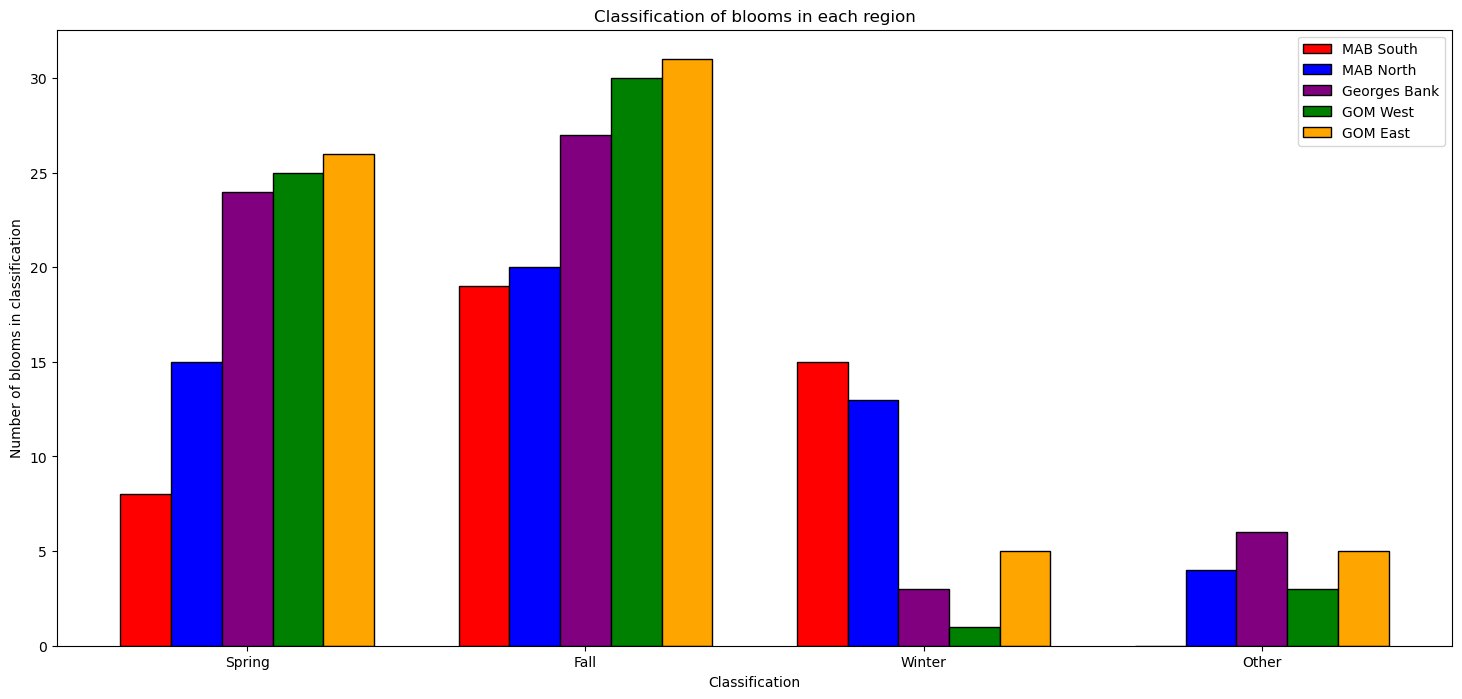

In [51]:
fig, ax = plt.subplots(figsize=(18,8))
width=0.15
classifications = ['Spring', 'Fall', 'Winter', 'Other']
x = np.arange(len(classifications))
def counts(df):
    counting = df['Bloom Classification'].value_counts()
    aligned_counts = counting.reindex(classifications,fill_value=0)
    return aligned_counts

counts_MABS = counts(bloom_MABS)
counts_MABN = counts(bloom_MABN)
counts_GB = counts(bloom_GB)
counts_GOMW = counts(bloom_GOMW)
counts_GOME = counts(bloom_GOME)

ax.bar(x-2*width,counts_MABS,color='red',label='MAB South',edgecolor='black',width=0.15)
ax.bar(x-width,counts_MABN,color='blue',label='MAB North',edgecolor='black',width=0.15)
ax.bar(x,counts_GB,color='purple',label='Georges Bank',edgecolor='black',width=0.15)
ax.bar(x+width,counts_GOMW,color='green',label='GOM West',edgecolor='black',width=0.15)
ax.bar(x+2*width,counts_GOME,color='orange',label='GOM East',edgecolor='black',width=0.15)
ax.set_xticks(x)
ax.set_xticklabels(classifications)
ax.legend()
ax.set_title("Classification of blooms in each region")
ax.set_ylabel("Number of blooms in classification")
ax.set_xlabel("Classification")

In [86]:
MABS_fall_start_DOY,MABN_fall_start_DOY,GB_fall_start_DOY,GOMW_fall_start_DOY,GOME_fall_start_DOY = [],[],[],[],[]
MABS_fall_year, MABN_fall_year, GB_fall_year, GOMW_fall_year, GOME_fall_year = [],[],[],[],[]
x_fall_lists = [MABS_fall_start_DOY,MABN_fall_start_DOY,GB_fall_start_DOY,GOMW_fall_start_DOY,GOME_fall_start_DOY]
y_fall_lists = [MABS_fall_year, MABN_fall_year, GB_fall_year, GOMW_fall_year, GOME_fall_year]
data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]

MABS_spring_start_DOY,MABN_spring_start_DOY,GB_spring_start_DOY,GOMW_spring_start_DOY,GOME_spring_start_DOY = [],[],[],[],[]
MABS_spring_year, MABN_spring_year, GB_spring_year, GOMW_spring_year, GOME_spring_year = [],[],[],[],[]
x_spring_lists = [MABS_spring_start_DOY,MABN_spring_start_DOY,GB_spring_start_DOY,GOMW_spring_start_DOY,GOME_spring_start_DOY]
y_spring_lists = [MABS_spring_year, MABN_spring_year, GB_spring_year, GOMW_spring_year, GOME_spring_year]

for x in range(5):
    dataset = data[x]
    bloom_ID = dataset['Bloom ID'].tolist()
    start_DOYs = dataset['Integrated chl-a'].tolist()
    years = dataset['Year'].tolist()
    bloom_classification = dataset['Bloom Classification'].tolist()
    for i in bloom_ID:
        bloom_class = bloom_classification[i-1]
        if bloom_class == 'Fall':
            start_DOY_list = x_fall_lists[x]
            year_list = y_fall_lists[x]
            start_DOY_fall_bloom = start_DOYs[i-1]
            year = years[i-1]
            start_DOY_list.append(start_DOY_fall_bloom)
            year_list.append(year)
        elif bloom_class == 'Spring':
            start_DOY_list = x_spring_lists[x]
            year_list = y_spring_lists[x]
            start_DOY_spring_bloom = start_DOYs[i-1]
            year = years[i-1]
            start_DOY_list.append(start_DOY_spring_bloom)
            year_list.append(year)

In [ ]:
x_data= [MABS_fall_year, MABN_fall_year, GB_fall_year, GOMW_fall_year, GOME_fall_year]
y_data = [MABS_fall_start_DOY,MABN_fall_start_DOY,GB_fall_start_DOY,GOMW_fall_start_DOY,GOME_fall_start_DOY]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14,8))
axes_flat = axes.flatten()
titles = ['Middle Atlantic Bight South','Middle Atlantic Bight North','Georges Bank','Gulf of Maine West','Gulf of Maine East']
x_ticks = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
x_labels = ['1998','1999','2000','2001','2002','2003','2004','2005','2006','2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']
for i in range(5):
    sns.regplot(
        x=x_data[i],
        y=y_data[i],
        ax=axes_flat[i],
        color=f"C{i}"
    )
    slope,intercept,r_value,p_value,std_err = stats.linregress(x_data[i],y_data[i])
    r_square = r_value**2
    stats_text = f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_square:.2f}\np-value = {p_value:.2f}"
    axes_flat[i].text(
        0.05,0.95,
        stats_text,
        transform=axes_flat[i].transAxes,
        fontsize=10,
        verticalalignment='top'
    )
    axes_flat[i].set_title(titles[i])
    axes_flat[i].set_xlabel('Year')
    axes_flat[i].set_ylabel('Fall Bloom Duration (days)')
    axes_flat[i].set_xticks(x_ticks)
    axes_flat[i].set_xticklabels(x_labels,rotation=90)
axes_flat[5].set_visible(False)
fig.suptitle("Fall Bloom Duration by Region")
plt.tight_layout()

In [194]:
spring_bloom_int_chl = []
fall_bloom_int_chl = []
winter_bloom_int_chl = []
other_bloom_int_chl = []
data = bloom_MABS
bloom_ID = data['Bloom ID'].tolist()
int_chl = data['Integrated chl-a'].tolist()
years = data['Year'].tolist()
bloom_classification = data['Bloom Classification'].tolist()
for i in range(len(bloom_ID)):
    bloom_class = bloom_classification[i]
    if bloom_class == 'Spring':
        int_chl_bloom = int_chl[i]
        spring_bloom_int_chl.append(int_chl_bloom)
    elif bloom_class == 'Fall':
        int_chl_bloom = int_chl[i]
        fall_bloom_int_chl.append(int_chl_bloom)
    elif bloom_class == 'Winter':
        int_chl_bloom = int_chl[i]
        winter_bloom_int_chl.append(int_chl_bloom)
    else:
        int_chl_bloom = int_chl[i]
        other_bloom_int_chl.append(int_chl_bloom) 

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(14,8),sharex=True)
MABS_pivot = bloom_MABS.pivot_table(
    values='Integrated chl-a',
    index='Year',
    columns='Bloom Classification',
    aggfunc='sum',
    fill_value=0
)
MABN_pivot = bloom_MABN.pivot_table(
    values='Integrated chl-a',
    index='Year',
    columns='Bloom Classification',
    aggfunc='sum',
    fill_value=0
)
GB_pivot = bloom_GB.pivot_table(
    values='Integrated chl-a',
    index='Year',
    columns='Bloom Classification',
    aggfunc='sum',
    fill_value=0
)
GOMW_pivot = bloom_GOMW.pivot_table(
    values='Integrated chl-a',
    index='Year',
    columns='Bloom Classification',
    aggfunc='sum',
    fill_value=0
)
GOME_pivot = bloom_GOME.pivot_table(
    values='Integrated chl-a',
    index='Year',
    columns='Bloom Classification',
    aggfunc='sum',
    fill_value=0
)
axes_flat = axes.flatten()
MABS_pivot.plot(kind='bar',stacked=True,ax=axes_flat[0],legend=False)
axes_flat[0].set_xlabel('Year')
axes_flat[0].set_ylabel('Integrated Chlorophyll ($mg/m^3 * days$)')
axes_flat[0].set_title("Middle Atlantic Bight South")

MABN_pivot.plot(kind='bar',stacked=True,ax=axes_flat[1],legend=False)
axes_flat[1].set_xlabel('Year')
axes_flat[1].set_ylabel('Integrated Chlorophyll ($mg/m^3 * days$)')
axes_flat[1].set_title("Middle Atlantic Bight North")

GB_pivot.plot(kind='bar',stacked=True,ax=axes_flat[2],legend=False)
axes_flat[2].set_xlabel('Year')
axes_flat[2].set_ylabel('Integrated Chlorophyll ($mg/m^3 * days$)')
axes_flat[2].set_title("Georges Bank")

GOMW_pivot.plot(kind='bar',stacked=True,ax=axes_flat[3],legend=False)
axes_flat[3].set_xlabel('Year')
axes_flat[3].set_ylabel('Integrated Chlorophyll ($mg/m^3 * days$)')
axes_flat[3].set_title("Gulf of Maine West")

GOME_pivot.plot(kind='bar',stacked=True,ax=axes_flat[4],legend=False)
axes_flat[4].set_xlabel('Year')
axes_flat[4].set_ylabel('Integrated Chlorophyll ($mg/m^3 * days$)')
axes_flat[4].set_title("Gulf of Maine East")

axes_flat[5].set_visible(False)
handles,labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles,labels,title='Bloom Classification',loc='upper right')
plt.suptitle("Regional Integrated Chlorophyll")
plt.tight_layout()
plt.show()